# **Goal**: Based on data containing reviews about game companies and their associated sentiment labels, create sentiment-specific word clouds (regardless of the game company entities).

# Data Load

In [1]:
# Setting the retina configuration makes the text appear sharper.
# It prevents the font from appearing blurry around the edges.
%config InlineBackend.figure_format = 'retina'

In [2]:
# To suppress warning messages:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/Unstructured Data Analysis/[Week 3] Text Preprocessing/data/twcs.csv')
data

,idx,Entity,Sentiment,Review
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


## Removing Duplicated idx and Keeping Only the First Value

In [5]:
data_unique = data.drop_duplicates(subset = 'idx', keep = 'first')
data_unique

,idx,Entity,Sentiment,Review
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
12,2403,Borderlands,Neutral,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM..."
18,2404,Borderlands,Positive,that was the first borderlands session in a lo...
24,2405,Borderlands,Negative,the biggest dissappoinment in my life came out...
...,...,...,...,...
74652,9196,Nvidia,Negative,Cheap doesn't mean better btw! . . techsall.co...
74658,9197,Nvidia,Neutral,Nvidia doesn’t want to give up its 2017 ‘crypt...
74664,9198,Nvidia,Negative,Nvidia really delayed the 3070 2 weeks .
74670,9199,Nvidia,Positive,Let no elim go unnoticed. . . . NVIDIA Highlig...


# Text Preprocessing

In [6]:
# Import the 're' module, which provides support for regular expressions
import re

# Define a function 'clean_text' that takes input 'd' and cleans it
def clean_text(d):
    # Convert the input to a lowercase string
    d = str(d).lower()
    # Use regular expression to replace all non-Korean, non-English, non-numeric characters with a space
    d = re.sub(r"[^\uAC00-\uD7A30-9a-zA-Z\s]", " ", d)
    # Return the cleaned text
    return d

# Apply the 'clean_text' function to the 'Review' column of the 'data_unique' dataframe
data_unique['Review'] = data_unique['Review'].apply(clean_text)

# Splitting Data by Sentiment (Positive, Neutral, Negative)

In [7]:
import pandas as pd

# Create separate dataframes for each sentiment.
positive_df = data_unique[data_unique['Sentiment'] == 'Positive']
neutral_df = data_unique[data_unique['Sentiment'] == 'Neutral']
negative_df = data_unique[data_unique['Sentiment'] == 'Negative']

In [8]:
# Reset the index.
positive_df = positive_df.reset_index(drop=True)
neutral_df = neutral_df.reset_index(drop=True)
negative_df = negative_df.reset_index(drop=True)

In [9]:
# Check each dataframe
positive_df

,idx,Entity,Sentiment,Review
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2402,Borderlands,Positive,so i spent a few hours making something for fu...
2,2404,Borderlands,Positive,that was the first borderlands session in a lo...
3,2406,Borderlands,Positive,we finished borderlands 3 finally yas thank y...
4,2412,Borderlands,Positive,going to finish up borderlands 2 today i ve g...
...,...,...,...,...
3467,9190,Nvidia,Positive,this news about the nvidia 3000 series is ligi...
3468,9193,Nvidia,Positive,love everything about it
3469,9194,Nvidia,Positive,checked for new gpu drivers today went to the...
3470,9199,Nvidia,Positive,let no elim go unnoticed nvidia highlig...


In [10]:
# Check each dataframe
neutral_df

,idx,Entity,Sentiment,Review
0,2403,Borderlands,Neutral,rock hard la varlope rare powerful handsom...
1,2408,Borderlands,Neutral,check out this epic streamer
2,2409,Borderlands,Neutral,blaming sight for tardiness a little bit of b...
3,2411,Borderlands,Neutral,
4,2414,Borderlands,Neutral,one of our own profzeroo is live w borderla...
...,...,...,...,...
3048,9184,Nvidia,Neutral,think im gonna screw around with this nvidia b...
3049,9185,Nvidia,Neutral,heard people are having issues with ordering t...
3050,9192,Nvidia,Neutral,save 500 on the aero 15 oled award winning ...
3051,9195,Nvidia,Neutral,nvidia released a security update for its driv...


In [11]:
# Check each dataframe
negative_df

,idx,Entity,Sentiment,Review
0,2405,Borderlands,Negative,the biggest dissappoinment in my life came out...
1,2407,Borderlands,Negative,man gearbox really needs to fix this dissapoin...
2,2410,Borderlands,Negative,why does like every man in borderlands have sl...
3,2417,Borderlands,Negative,grounded almost looked pretty cool even despit...
4,2419,Borderlands,Negative,borderlands how do i submit a complaint your...
...,...,...,...,...
3752,9188,Nvidia,Negative,if my display only support freesync am i scre...
3753,9189,Nvidia,Negative,nvidia should cancel any order that is suspect...
3754,9191,Nvidia,Negative,nvidiageforce the hell with you nvidia you a...
3755,9196,Nvidia,Negative,cheap doesn t mean better btw techsall co...


# Word Tokenization

In [12]:
# We perform word tokenization using NLTK's RegexpTokenizer.
import nltk
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer("[\w']+")

positive_df['text'] = positive_df.apply(lambda row: tokenizer.tokenize(row['Review']), axis=1)
neutral_df['text'] = neutral_df.apply(lambda row: tokenizer.tokenize(row['Review']), axis=1)
negative_df['text'] = negative_df.apply(lambda row: tokenizer.tokenize(row['Review']), axis=1)

In [13]:
positive_df

,idx,Entity,Sentiment,Review,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m..."
1,2402,Borderlands,Positive,so i spent a few hours making something for fu...,"[so, i, spent, a, few, hours, making, somethin..."
2,2404,Borderlands,Positive,that was the first borderlands session in a lo...,"[that, was, the, first, borderlands, session, ..."
3,2406,Borderlands,Positive,we finished borderlands 3 finally yas thank y...,"[we, finished, borderlands, 3, finally, yas, t..."
4,2412,Borderlands,Positive,going to finish up borderlands 2 today i ve g...,"[going, to, finish, up, borderlands, 2, today,..."
...,...,...,...,...,...
3467,9190,Nvidia,Positive,this news about the nvidia 3000 series is ligi...,"[this, news, about, the, nvidia, 3000, series,..."
3468,9193,Nvidia,Positive,love everything about it,"[love, everything, about, it]"
3469,9194,Nvidia,Positive,checked for new gpu drivers today went to the...,"[checked, for, new, gpu, drivers, today, went,..."
3470,9199,Nvidia,Positive,let no elim go unnoticed nvidia highlig...,"[let, no, elim, go, unnoticed, nvidia, highlig..."


In [14]:
neutral_df

,idx,Entity,Sentiment,Review,text
0,2403,Borderlands,Neutral,rock hard la varlope rare powerful handsom...,"[rock, hard, la, varlope, rare, powerful, hand..."
1,2408,Borderlands,Neutral,check out this epic streamer,"[check, out, this, epic, streamer]"
2,2409,Borderlands,Neutral,blaming sight for tardiness a little bit of b...,"[blaming, sight, for, tardiness, a, little, bi..."
3,2411,Borderlands,Neutral,,[]
4,2414,Borderlands,Neutral,one of our own profzeroo is live w borderla...,"[one, of, our, own, profzeroo, is, live, w, bo..."
...,...,...,...,...,...
3048,9184,Nvidia,Neutral,think im gonna screw around with this nvidia b...,"[think, im, gonna, screw, around, with, this, ..."
3049,9185,Nvidia,Neutral,heard people are having issues with ordering t...,"[heard, people, are, having, issues, with, ord..."
3050,9192,Nvidia,Neutral,save 500 on the aero 15 oled award winning ...,"[save, 500, on, the, aero, 15, oled, award, wi..."
3051,9195,Nvidia,Neutral,nvidia released a security update for its driv...,"[nvidia, released, a, security, update, for, i..."


In [15]:
negative_df

,idx,Entity,Sentiment,Review,text
0,2405,Borderlands,Negative,the biggest dissappoinment in my life came out...,"[the, biggest, dissappoinment, in, my, life, c..."
1,2407,Borderlands,Negative,man gearbox really needs to fix this dissapoin...,"[man, gearbox, really, needs, to, fix, this, d..."
2,2410,Borderlands,Negative,why does like every man in borderlands have sl...,"[why, does, like, every, man, in, borderlands,..."
3,2417,Borderlands,Negative,grounded almost looked pretty cool even despit...,"[grounded, almost, looked, pretty, cool, even,..."
4,2419,Borderlands,Negative,borderlands how do i submit a complaint your...,"[borderlands, how, do, i, submit, a, complaint..."
...,...,...,...,...,...
3752,9188,Nvidia,Negative,if my display only support freesync am i scre...,"[if, my, display, only, support, freesync, am,..."
3753,9189,Nvidia,Negative,nvidia should cancel any order that is suspect...,"[nvidia, should, cancel, any, order, that, is,..."
3754,9191,Nvidia,Negative,nvidiageforce the hell with you nvidia you a...,"[nvidiageforce, the, hell, with, you, nvidia, ..."
3755,9196,Nvidia,Negative,cheap doesn t mean better btw techsall co...,"[cheap, doesn, t, mean, better, btw, techsall,..."


# POS Tagging

In [16]:
# To revert tokenization for part-of-speech tagging (detokenization):
positive_detokenized_doc = []
for i in range(len(positive_df['text'])):
    t = ' '.join(positive_df['text'][i])
    positive_detokenized_doc.append(t)

positive_tokens = ' '.join(positive_detokenized_doc)
positive_tokens = positive_tokens.split(' ')
print("The total number of tokens with positive sentiment is", len(positive_tokens),'.')

The total number of tokens with positive sentiment is 60293 .


In [17]:
# To revert tokenization for part-of-speech tagging (detokenization):
neutral_detokenized_doc = []
for i in range(len(neutral_df['text'])):
    t = ' '.join(neutral_df['text'][i])
    neutral_detokenized_doc.append(t)

neutral_tokens = ' '.join(neutral_detokenized_doc)
neutral_tokens = neutral_tokens.split(' ')
print("The total number of tokens with neutral sentiment is", len(neutral_tokens),'.')

The total number of tokens with neutral sentiment is 61525 .


In [18]:
# To revert tokenization for part-of-speech tagging (detokenization):
negative_detokenized_doc = []
for i in range(len(negative_df['text'])):
    t = ' '.join(negative_df['text'][i])
    negative_detokenized_doc.append(t)

negative_tokens = ' '.join(negative_detokenized_doc)
negative_tokens = negative_tokens.split(' ')
print("The total number of tokens with negative sentiment is", len(negative_tokens),'.')

The total number of tokens with negative sentiment is 75252 .


In [19]:
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [20]:
# pos tagging
positive_pos_tag = nltk.pos_tag(positive_tokens)

In [21]:
# pos tagging
neutral_pos_tag = nltk.pos_tag(neutral_tokens)

In [22]:
# pos tagging
negative_pos_tag = nltk.pos_tag(negative_tokens)

In [23]:
# Assigning a special token to fix POS tagging errors.
special_token = {'saw':'VBD'}

In [24]:
def special_func(token):
#     print(token,token[0],token[1])
    if token[0] in list(special_token.keys()):
        token  = tuple([token[0],special_token[token[0]]])
    else:
        pass
    return token

In [25]:
positive_new_pos_tagged = [special_func(data) for data in positive_pos_tag]

In [26]:
neutral_new_pos_tagged = [special_func(data) for data in neutral_pos_tag]

In [27]:
negative_new_pos_tagged = [special_func(data) for data in negative_pos_tag]

In [28]:
positive_pos_tag = positive_new_pos_tagged

In [29]:
neutral_pos_tag = neutral_new_pos_tagged

In [30]:
negative_pos_tag = negative_new_pos_tagged

In [31]:
tag_df = pd.read_csv('/content/drive/MyDrive/Unstructured Data Analysis/[Week 3] Text Preprocessing/data/tagging df.csv', encoding='utf-8').drop('Kor_tag', axis='columns')

In [32]:
tag_df

,POS,Eng_tag
0,noun,"['NN', 'NNS', 'NNP', 'NNPS']"
1,pronoun,"['PRP', 'WP', 'PRP$', 'WP$']"
2,verb,"['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ']"
3,adjective,"['JJ', 'JJR', 'JJS']"
4,adverb,"['RB', 'RBR', 'RBS', 'WRB', 'EX', 'RP']"
5,prep&conj,"['TO', 'IN', 'CC']"
6,determiner,"['DT', 'PDT', 'WDT']"
7,interjection,['UH']
8,number,['CD']
9,foreignW,['FW']


In [33]:
#create blank list to append values
noun = []
pronoun = []
verb = []
adjective = []
adverb = []
prepnconj = []
determiner = []
interjection = []
number = []
foreignW = []
modal = []
josa = []
possesiveS = []
etc = []

In [34]:
for i in range(len(positive_pos_tag)):
    if positive_pos_tag[i][1] in tag_df['Eng_tag'][1]:
        pronoun.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][0]:
        noun.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][2]:
        verb.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][3]:
        adjective.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][4]:
        adverb.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][5]:
        prepnconj.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][6]:
        determiner.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][7]:
        interjection.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][8]:
        number.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][9]:
        foreignW.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][10]:
        modal.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][11]:
        josa.append(positive_pos_tag[i])
    elif positive_pos_tag[i][1] in tag_df['Eng_tag'][12]:
        possesiveS.append(positive_pos_tag[i])
    else:
        etc.append(positive_pos_tag[i])

In [35]:
tagged_list = [noun, pronoun, verb, adjective, adverb, prepnconj, determiner,
               interjection, number, foreignW, modal, josa, possesiveS, etc]
tag_df['Eng_tagged']=tagged_list

In [36]:
total = len(positive_pos_tag)
nounN = round(len(noun)/total*100, 2)
pronounN = round(len(pronoun)/total*100, 2)
verbN = round(len(verb)/total*100, 2)
adjN = round(len(adjective)/total*100, 2)
advN = round(len(adverb)/total*100, 2)
prepnconjN = round(len(prepnconj)/total*100, 2)
detN = round(len(determiner)/total*100, 2)
intN = round(len(interjection)/total*100, 2)
numN = round(len(number)/total*100, 2)
forN = round(len(foreignW)/total*100, 2)
modalN = round(len(modal)/total*100, 2)
josaN = round(len(josa)/total*100, 2)
posSN = round(len(possesiveS)/total*100, 2)
etcN = round(len(etc)/total*100, 2)

In [37]:
tag_df.insert(3,'Eng_tagged_%',[nounN, pronounN, verbN, adjN, advN, prepnconjN, detN, \
               intN, numN, forN, modalN, josaN, posSN, etcN])

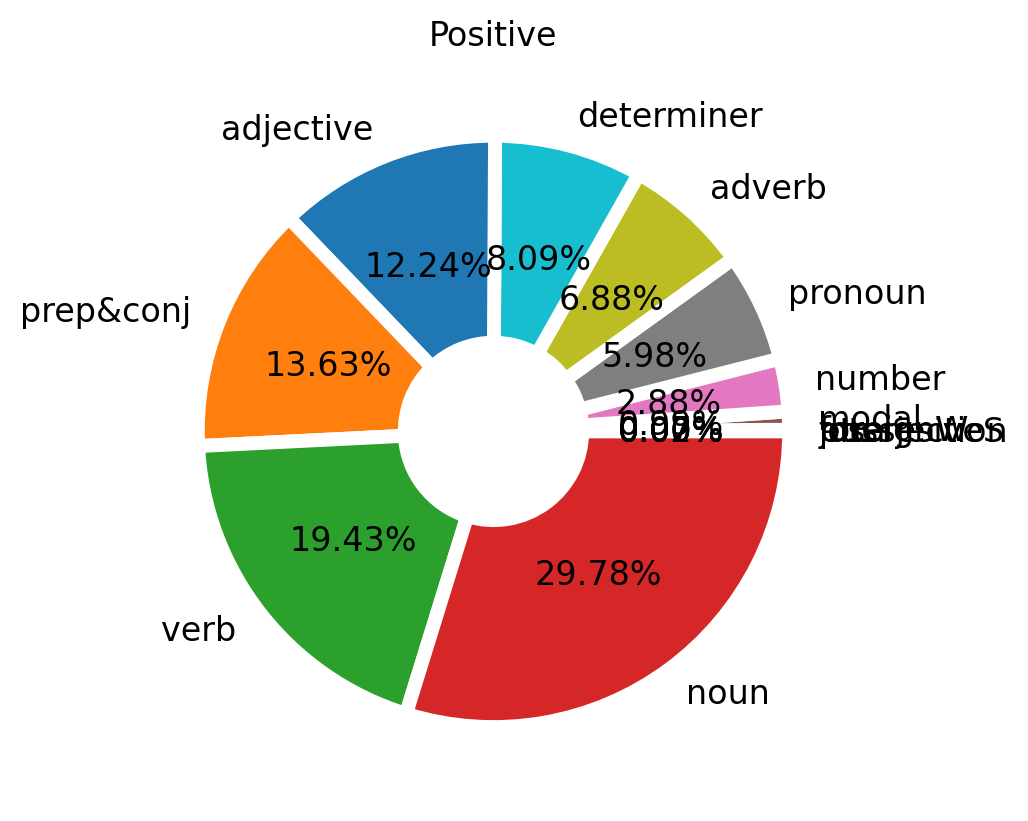

In [38]:
import matplotlib.pyplot as plt

tag_df1 = tag_df.sort_values(by='Eng_tagged_%')
ratio = tag_df1['Eng_tagged_%']
labels = tag_df1['POS']
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

plt.pie(ratio, labels=labels, autopct='%.2f%%', wedgeprops=wedgeprops, textprops={'fontsize': 12})
plt.title('Positive')  # 제목 추가
plt.rcParams['figure.figsize'] = (10, 10)
plt.show()

In [39]:
for i in range(len(neutral_pos_tag)):
    if neutral_pos_tag[i][1] in tag_df['Eng_tag'][1]:
        pronoun.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][0]:
        noun.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][2]:
        verb.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][3]:
        adjective.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][4]:
        adverb.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][5]:
        prepnconj.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][6]:
        determiner.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][7]:
        interjection.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][8]:
        number.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][9]:
        foreignW.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][10]:
        modal.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][11]:
        josa.append(neutral_pos_tag[i])
    elif neutral_pos_tag[i][1] in tag_df['Eng_tag'][12]:
        possesiveS.append(neutral_pos_tag[i])
    else:
        etc.append(neutral_pos_tag[i])

In [40]:
total = len(neutral_pos_tag)
nounN = round(len(noun)/total*100, 2)
pronounN = round(len(pronoun)/total*100, 2)
verbN = round(len(verb)/total*100, 2)
adjN = round(len(adjective)/total*100, 2)
advN = round(len(adverb)/total*100, 2)
prepnconjN = round(len(prepnconj)/total*100, 2)
detN = round(len(determiner)/total*100, 2)
intN = round(len(interjection)/total*100, 2)
numN = round(len(number)/total*100, 2)
forN = round(len(foreignW)/total*100, 2)
modalN = round(len(modal)/total*100, 2)
josaN = round(len(josa)/total*100, 2)
posSN = round(len(possesiveS)/total*100, 2)
etcN = round(len(etc)/total*100, 2)

In [41]:
tag_df['Eng_tagged_%'] = [nounN, pronounN, verbN, adjN, advN, prepnconjN, detN,
                          intN, numN, forN, modalN, josaN, posSN, etcN]

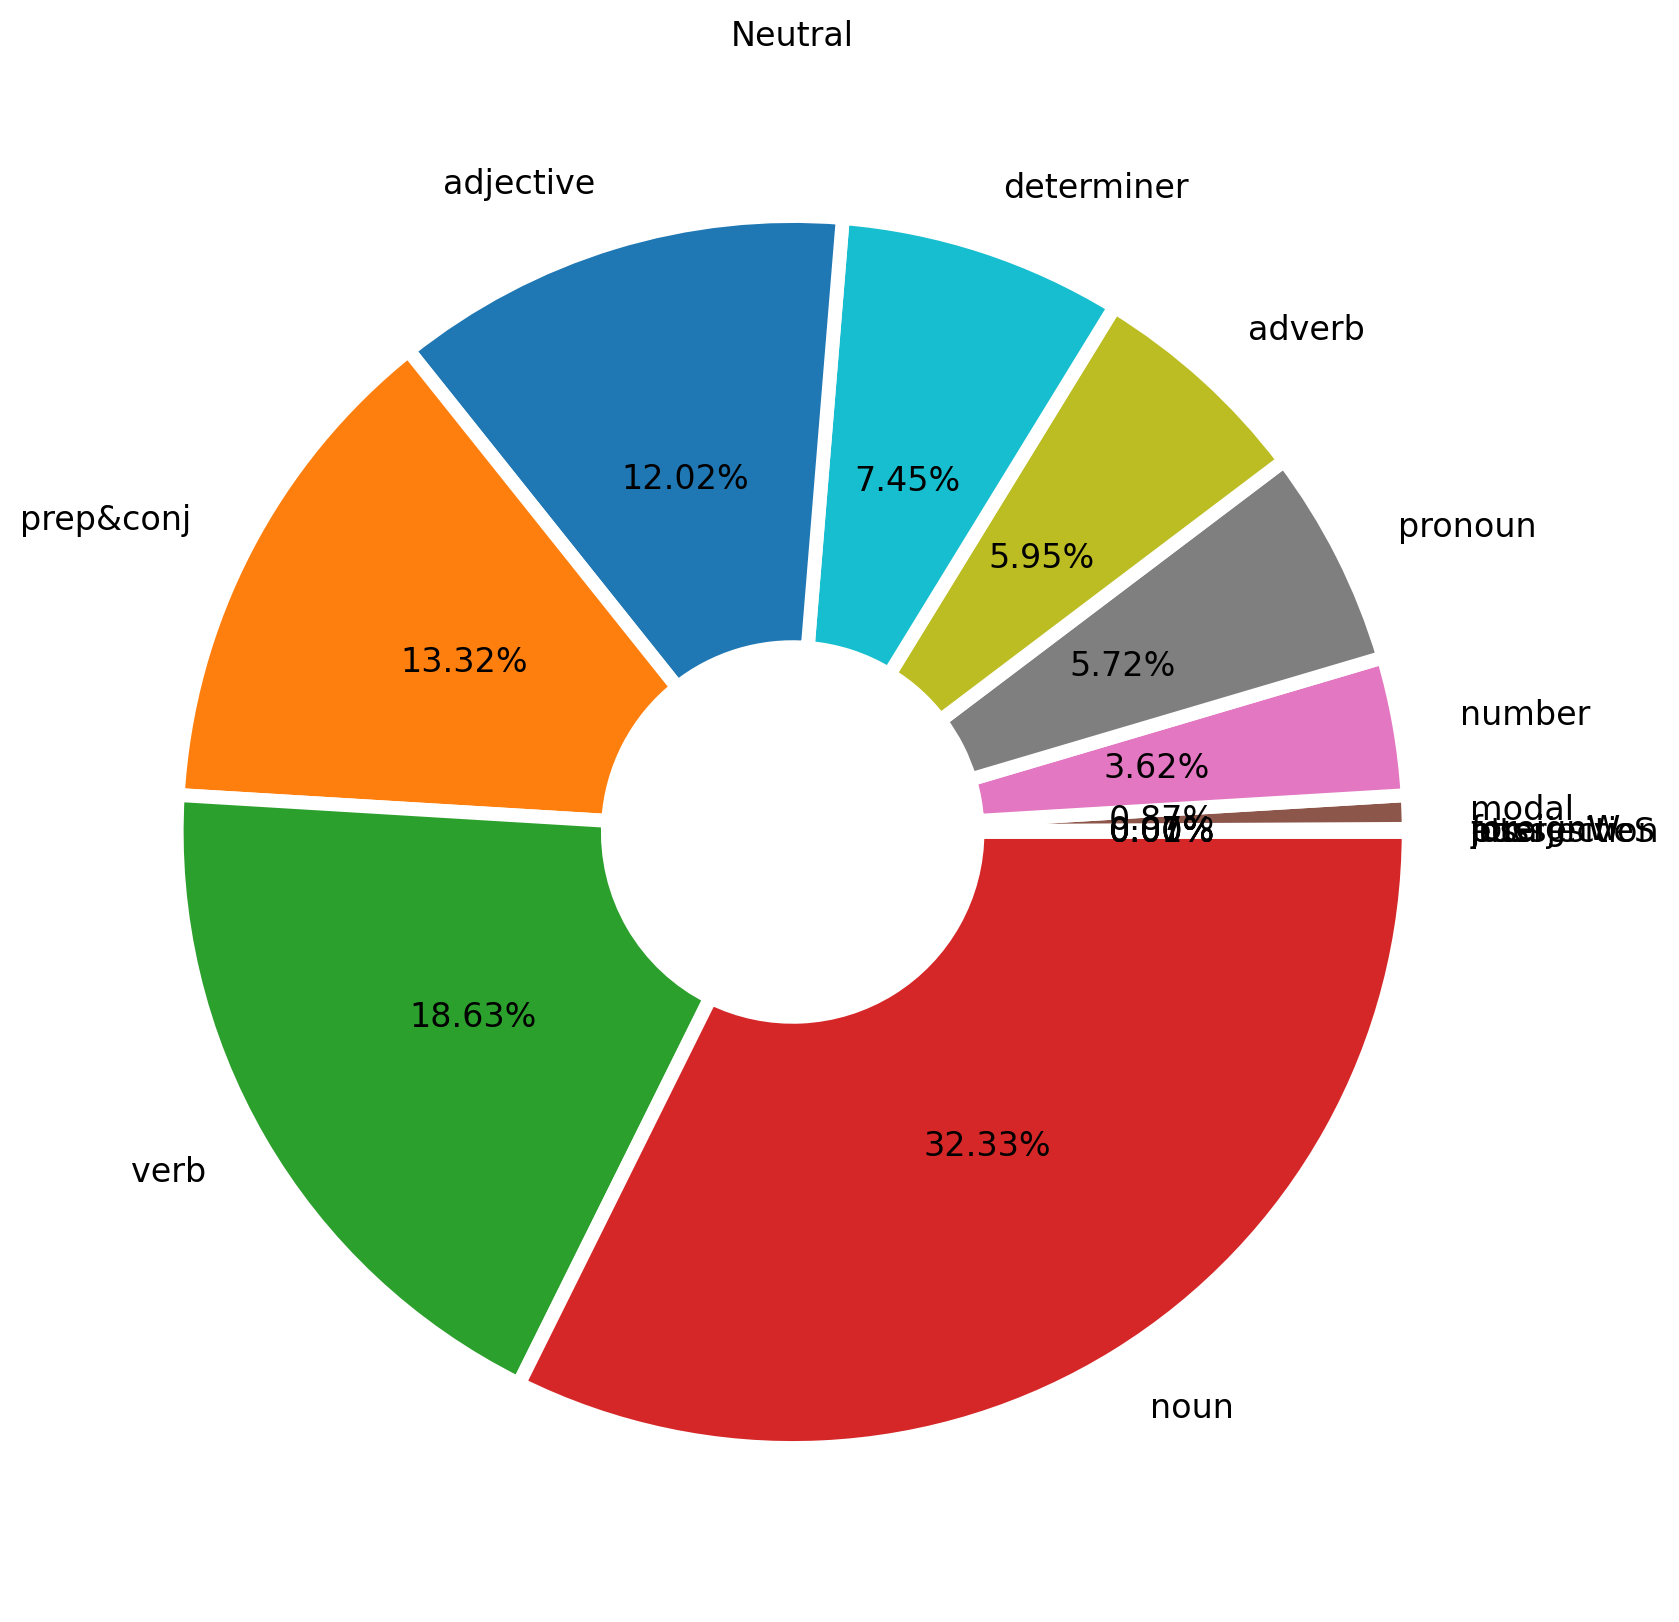

In [42]:
import matplotlib.pyplot as plt

tag_df1 = tag_df.sort_values(by='Eng_tagged_%')
ratio = tag_df1['Eng_tagged_%']
labels = tag_df1['POS']
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

plt.pie(ratio, labels=labels, autopct='%.2f%%', wedgeprops=wedgeprops, textprops={'fontsize': 12})
plt.title('Neutral')  # 제목 추가
plt.rcParams['figure.figsize'] = (10, 10)
plt.show()

In [43]:
for i in range(len(negative_pos_tag)):
    if negative_pos_tag[i][1] in tag_df['Eng_tag'][1]:
        pronoun.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][0]:
        noun.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][2]:
        verb.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][3]:
        adjective.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][4]:
        adverb.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][5]:
        prepnconj.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][6]:
        determiner.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][7]:
        interjection.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][8]:
        number.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][9]:
        foreignW.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][10]:
        modal.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][11]:
        josa.append(negative_pos_tag[i])
    elif negative_pos_tag[i][1] in tag_df['Eng_tag'][12]:
        possesiveS.append(negative_pos_tag[i])
    else:
        etc.append(negative_pos_tag[i])

In [44]:
total = len(negative_pos_tag)
nounN = round(len(noun)/total*100, 2)
pronounN = round(len(pronoun)/total*100, 2)
verbN = round(len(verb)/total*100, 2)
adjN = round(len(adjective)/total*100, 2)
advN = round(len(adverb)/total*100, 2)
prepnconjN = round(len(prepnconj)/total*100, 2)
detN = round(len(determiner)/total*100, 2)
intN = round(len(interjection)/total*100, 2)
numN = round(len(number)/total*100, 2)
forN = round(len(foreignW)/total*100, 2)
modalN = round(len(modal)/total*100, 2)
josaN = round(len(josa)/total*100, 2)
posSN = round(len(possesiveS)/total*100, 2)
etcN = round(len(etc)/total*100, 2)

In [45]:
tag_df['Eng_tagged_%'] = [nounN, pronounN, verbN, adjN, advN, prepnconjN, detN,
                          intN, numN, forN, modalN, josaN, posSN, etcN]

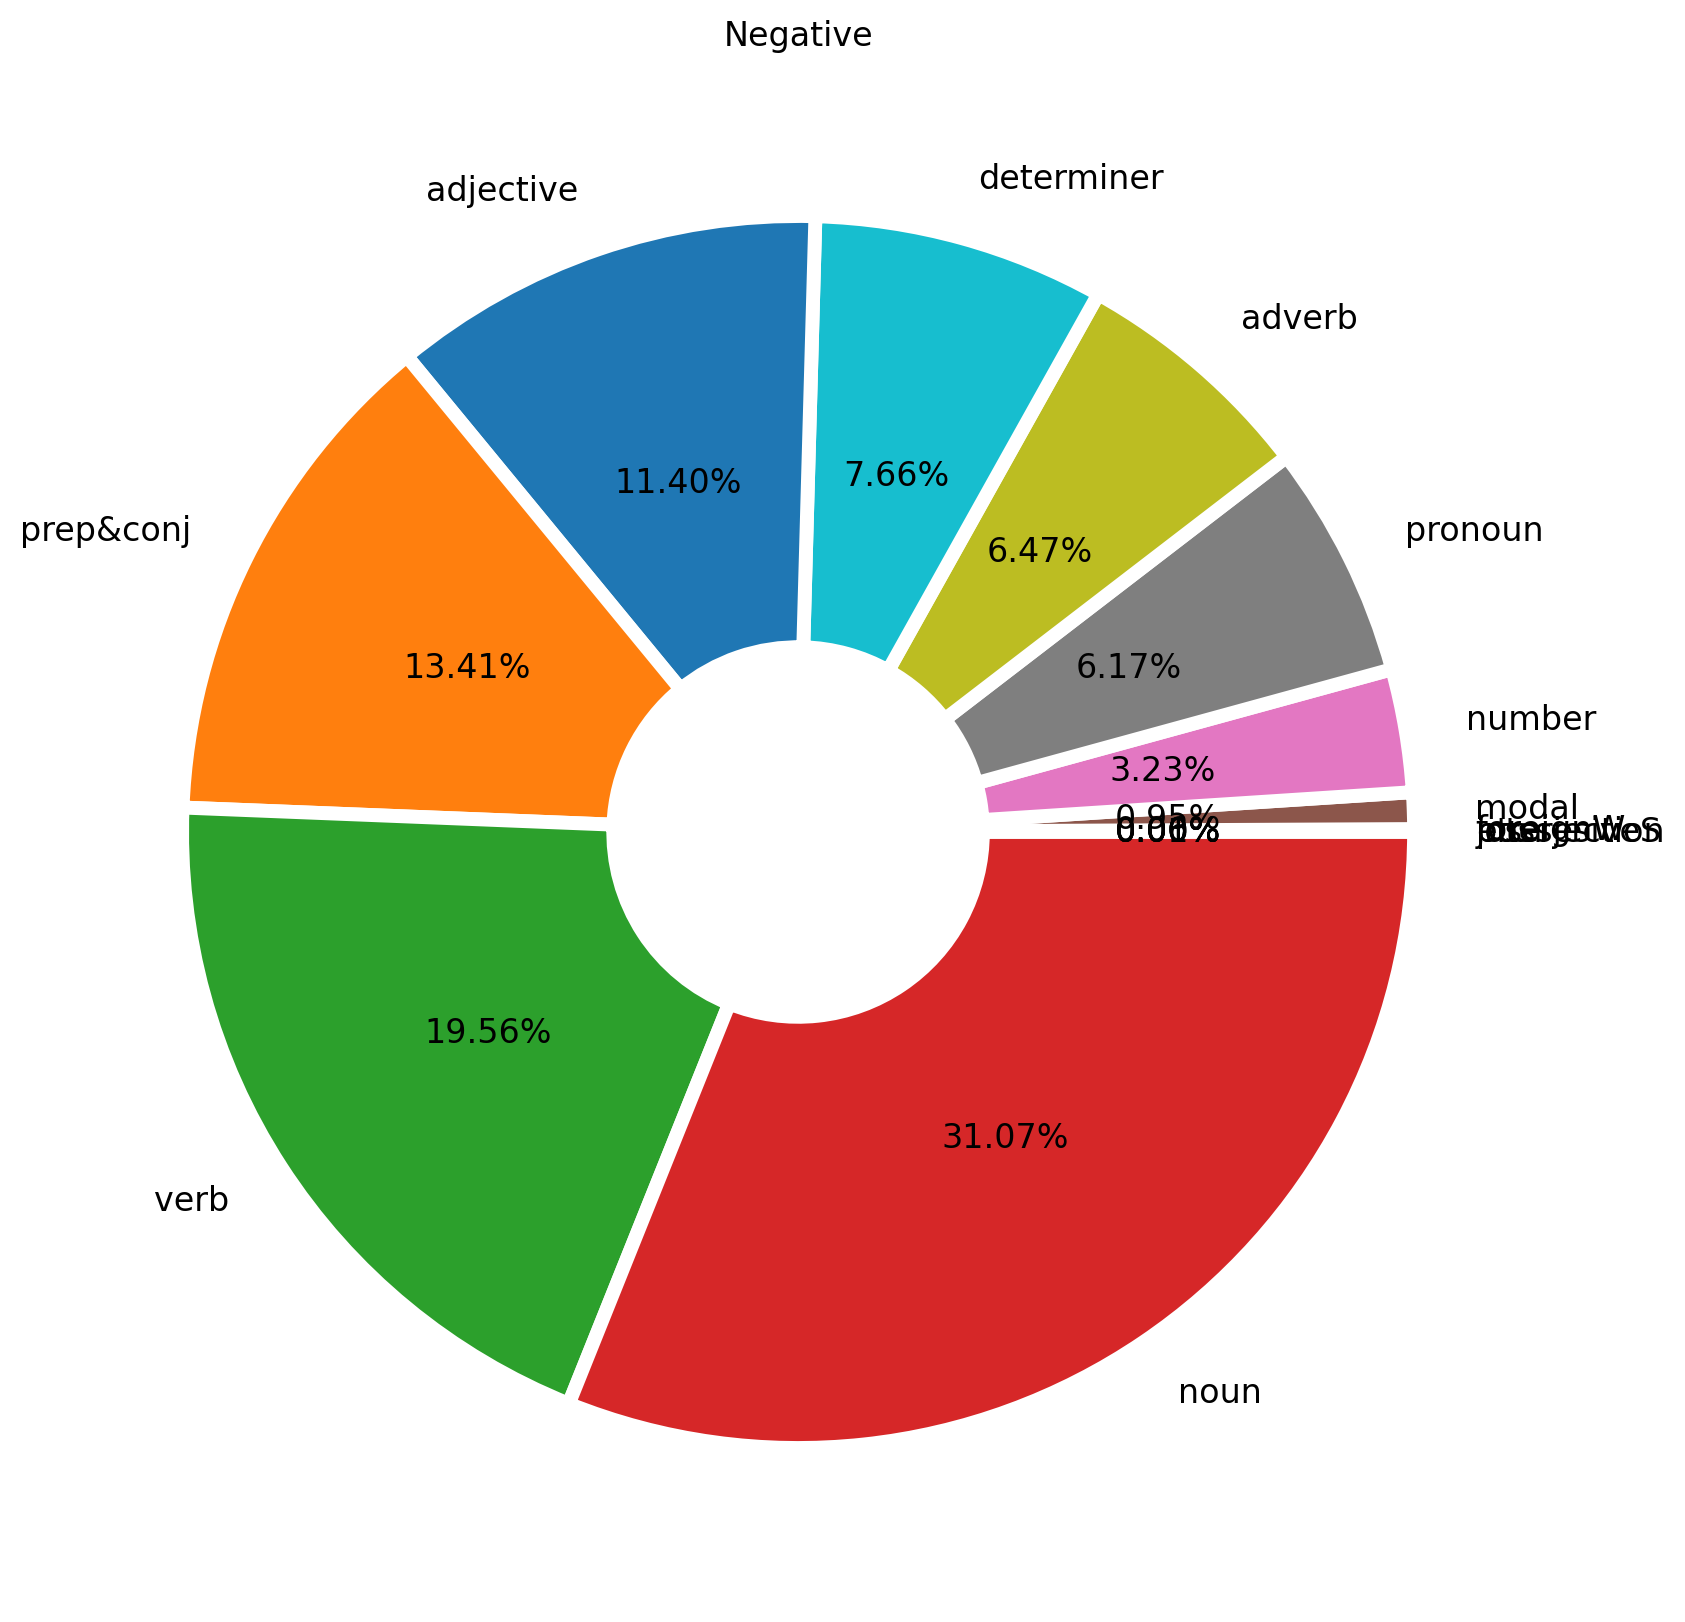

In [46]:
import matplotlib.pyplot as plt

tag_df1 = tag_df.sort_values(by='Eng_tagged_%')
ratio = tag_df1['Eng_tagged_%']
labels = tag_df1['POS']
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

plt.pie(ratio, labels=labels, autopct='%.2f%%', wedgeprops=wedgeprops, textprops={'fontsize': 12})
plt.title('Negative')  # 제목 추가
plt.rcParams['figure.figsize'] = (10, 10)
plt.show()

## Keyword Frequency Analysis

### Positive

### Text Preprocessing

### Lemmatization

In [47]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [48]:
# 품사를 고려한 표제어 추출을 시행합니다.
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

# POS tag
def pos_tagger(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

tokenized_doc = positive_df['text']

total_lemmmatized = []
for tokenized_sentence in tokenized_doc:
    # tokenize the sentence and find the POS tag for each token
    pos_tagged = nltk.pos_tag(tokenized_sentence)
    new_pos_tagged = [special_func(data) for data in pos_tagged]
    # As you may have noticed, the above pos tags are a little confusing.
    # we use our own pos_tagger function to make things simpler to understand.
    wordnet_tagged = list(map(lambda x: (x[0], pos_tagger(x[1])), new_pos_tagged))

    lemmatized_sentence = []
    for word, tag in wordnet_tagged:
        if tag is None:
            # if there is no available tag, append the token as is
            lemmatized_sentence.append(word)
        else:
            # else use the tag to lemmatize the token
            lemmatized_sentence.append(lemmatizer.lemmatize(word, tag))

    total_lemmmatized.append(lemmatized_sentence)

lemmatized_doc = pd.Series(total_lemmmatized)
lemmatized_doc[:5]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,0
0,"[im, get, on, borderland, and, i, will, murder..."
1,"[so, i, spend, a, few, hour, make, something, ..."
2,"[that, be, the, first, borderlands, session, i..."
3,"[we, finish, borderland, 3, finally, yas, than..."
4,"[go, to, finish, up, borderland, 2, today, i, ..."


### Stopwords Removal

In [49]:
# Lemmatization Considering Parts of Speech (POS)
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

# POS tag
def pos_tagger(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

tokenized_doc = positive_df['text']

total_lemmmatized = []
for tokenized_sentence in tokenized_doc:
    # tokenize the sentence and find the POS tag for each token
    pos_tagged = nltk.pos_tag(tokenized_sentence)
    new_pos_tagged = [special_func(data) for data in pos_tagged]
    # As you may have noticed, the above pos tags are a little confusing.
    # we use our own pos_tagger function to make things simpler to understand.
    wordnet_tagged = list(map(lambda x: (x[0], pos_tagger(x[1])), new_pos_tagged))

    lemmatized_sentence = []
    for word, tag in wordnet_tagged:
        if tag is None:
            # if there is no available tag, append the token as is
            lemmatized_sentence.append(word)
        else:
            # else use the tag to lemmatize the token
            lemmatized_sentence.append(lemmatizer.lemmatize(word, tag))

    total_lemmmatized.append(lemmatized_sentence)

lemmatized_doc = pd.Series(total_lemmmatized)
lemmatized_doc[:5]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,0
0,"[im, get, on, borderland, and, i, will, murder..."
1,"[so, i, spend, a, few, hour, make, something, ..."
2,"[that, be, the, first, borderlands, session, i..."
3,"[we, finish, borderland, 3, finally, yas, than..."
4,"[go, to, finish, up, borderland, 2, today, i, ..."


In [50]:
lemmatized_doc[:5]

,0
0,"[im, get, on, borderland, and, i, will, murder..."
1,"[so, i, spend, a, few, hour, make, something, ..."
2,"[that, be, the, first, borderlands, session, i..."
3,"[we, finish, borderland, 3, finally, yas, than..."
4,"[go, to, finish, up, borderland, 2, today, i, ..."


In [51]:
from nltk.corpus import stopwords
nltk.download('stopwords')

# Retrieve the list of stopwords from NLTK
stop_words = set(stopwords.words('english'))

# Remove stopwords
lemmatized_doc = [[word for word in doc if word.lower() not in stop_words and len(word) > 1] for doc in lemmatized_doc]

print(lemmatized_doc)

[['im', 'get', 'borderland', 'murder'], ['spend', 'hour', 'make', 'something', 'fun', 'know', 'huge', 'borderland', 'fan', 'maya', 'one', 'favorite', 'character', 'decide', 'make', 'wallpaper', 'pc', 'original', 'image', 'versus', 'creation', 'make', 'enjoy', 'pic', 'twitter', 'com', 'mlsi5wf9jg'], ['first', 'borderlands', 'session', 'long', 'time', 'actually', 'really', 'satisfying', 'combat', 'experience', 'get', 'really', 'good', 'kill'], ['finish', 'borderland', 'finally', 'yas', 'thank', 'hang', 'everyone', 'fun', 'try', 'stream', 'tomorrow', 'might', 'irl', 'stream', 'awayu', 'shall', 'see', 'thank', 'much', 'raid', 'mompou', 'mumpow', 'megamagwitch', 'kfdmitch'], ['go', 'finish', 'borderland', 'today', 'get', 'new', 'command', 'set', 'look', 'forward', 'good', 'stream', 'start', 'hour'], ['imma', 'probably', 'play', 'borderland', 'tps', 'bit', 'fun'], ['fuck', 'yessssssss'], ['finally', 'play', 'borderland', 'actual', 'game', 'play', 'great', 'almost', 'gun', 'feel', 'fun', 'nev

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [52]:
# Detokenization (Reversing the Tokenization Process)
detokenized_doc = []
for i in range(len(lemmatized_doc)):
    t = ' '.join(lemmatized_doc[i])
    detokenized_doc.append(t)
detokenized_doc[:5]

['im get borderland murder',
 'spend hour make something fun know huge borderland fan maya one favorite character decide make wallpaper pc original image versus creation make enjoy pic twitter com mlsi5wf9jg',
 'first borderlands session long time actually really satisfying combat experience get really good kill',
 'finish borderland finally yas thank hang everyone fun try stream tomorrow might irl stream awayu shall see thank much raid mompou mumpow megamagwitch kfdmitch',
 'go finish borderland today get new command set look forward good stream start hour']

In [53]:
lemmatized_text = detokenized_doc.copy()

In [54]:
detokenized_doc = ' '.join(detokenized_doc)
lemmatized_word = detokenized_doc.split(' ')
# Remove Empty Lists
lemmatized_word = [v for v in lemmatized_word if v]

In [55]:
lemmatized_word

['im',
 'get',
 'borderland',
 'murder',
 'spend',
 'hour',
 'make',
 'something',
 'fun',
 'know',
 'huge',
 'borderland',
 'fan',
 'maya',
 'one',
 'favorite',
 'character',
 'decide',
 'make',
 'wallpaper',
 'pc',
 'original',
 'image',
 'versus',
 'creation',
 'make',
 'enjoy',
 'pic',
 'twitter',
 'com',
 'mlsi5wf9jg',
 'first',
 'borderlands',
 'session',
 'long',
 'time',
 'actually',
 'really',
 'satisfying',
 'combat',
 'experience',
 'get',
 'really',
 'good',
 'kill',
 'finish',
 'borderland',
 'finally',
 'yas',
 'thank',
 'hang',
 'everyone',
 'fun',
 'try',
 'stream',
 'tomorrow',
 'might',
 'irl',
 'stream',
 'awayu',
 'shall',
 'see',
 'thank',
 'much',
 'raid',
 'mompou',
 'mumpow',
 'megamagwitch',
 'kfdmitch',
 'go',
 'finish',
 'borderland',
 'today',
 'get',
 'new',
 'command',
 'set',
 'look',
 'forward',
 'good',
 'stream',
 'start',
 'hour',
 'imma',
 'probably',
 'play',
 'borderland',
 'tps',
 'bit',
 'fun',
 'fuck',
 'yessssssss',
 'finally',
 'play',
 'borde

### Top 30 Most Frequent Words

In [56]:
from nltk import FreqDist

freq = FreqDist(lemmatized_word)
freq.most_common(30)

[('game', 561),
 ('play', 418),
 ('com', 408),
 ('love', 368),
 ('get', 364),
 ('good', 305),
 ('twitter', 300),
 ('pic', 297),
 ('like', 247),
 ('go', 235),
 ('new', 208),
 ('look', 203),
 ('best', 202),
 ('really', 199),
 ('one', 194),
 ('time', 188),
 ('great', 176),
 ('make', 168),
 ('fun', 167),
 ('wait', 167),
 ('see', 158),
 ('year', 142),
 ('thank', 138),
 ('dead', 129),
 ('red', 129),
 ('creed', 129),
 ('assassin', 124),
 ('come', 120),
 ('day', 120),
 ('redemption', 120)]

In [57]:
df_fq = pd.DataFrame.from_dict(freq, orient='index')
df_fq.columns = ['Frequency']
df_fq.index.name = 'keyword'

<Axes: title={'center': 'Word Frequency - Positive'}, xlabel='Samples', ylabel='Counts'>

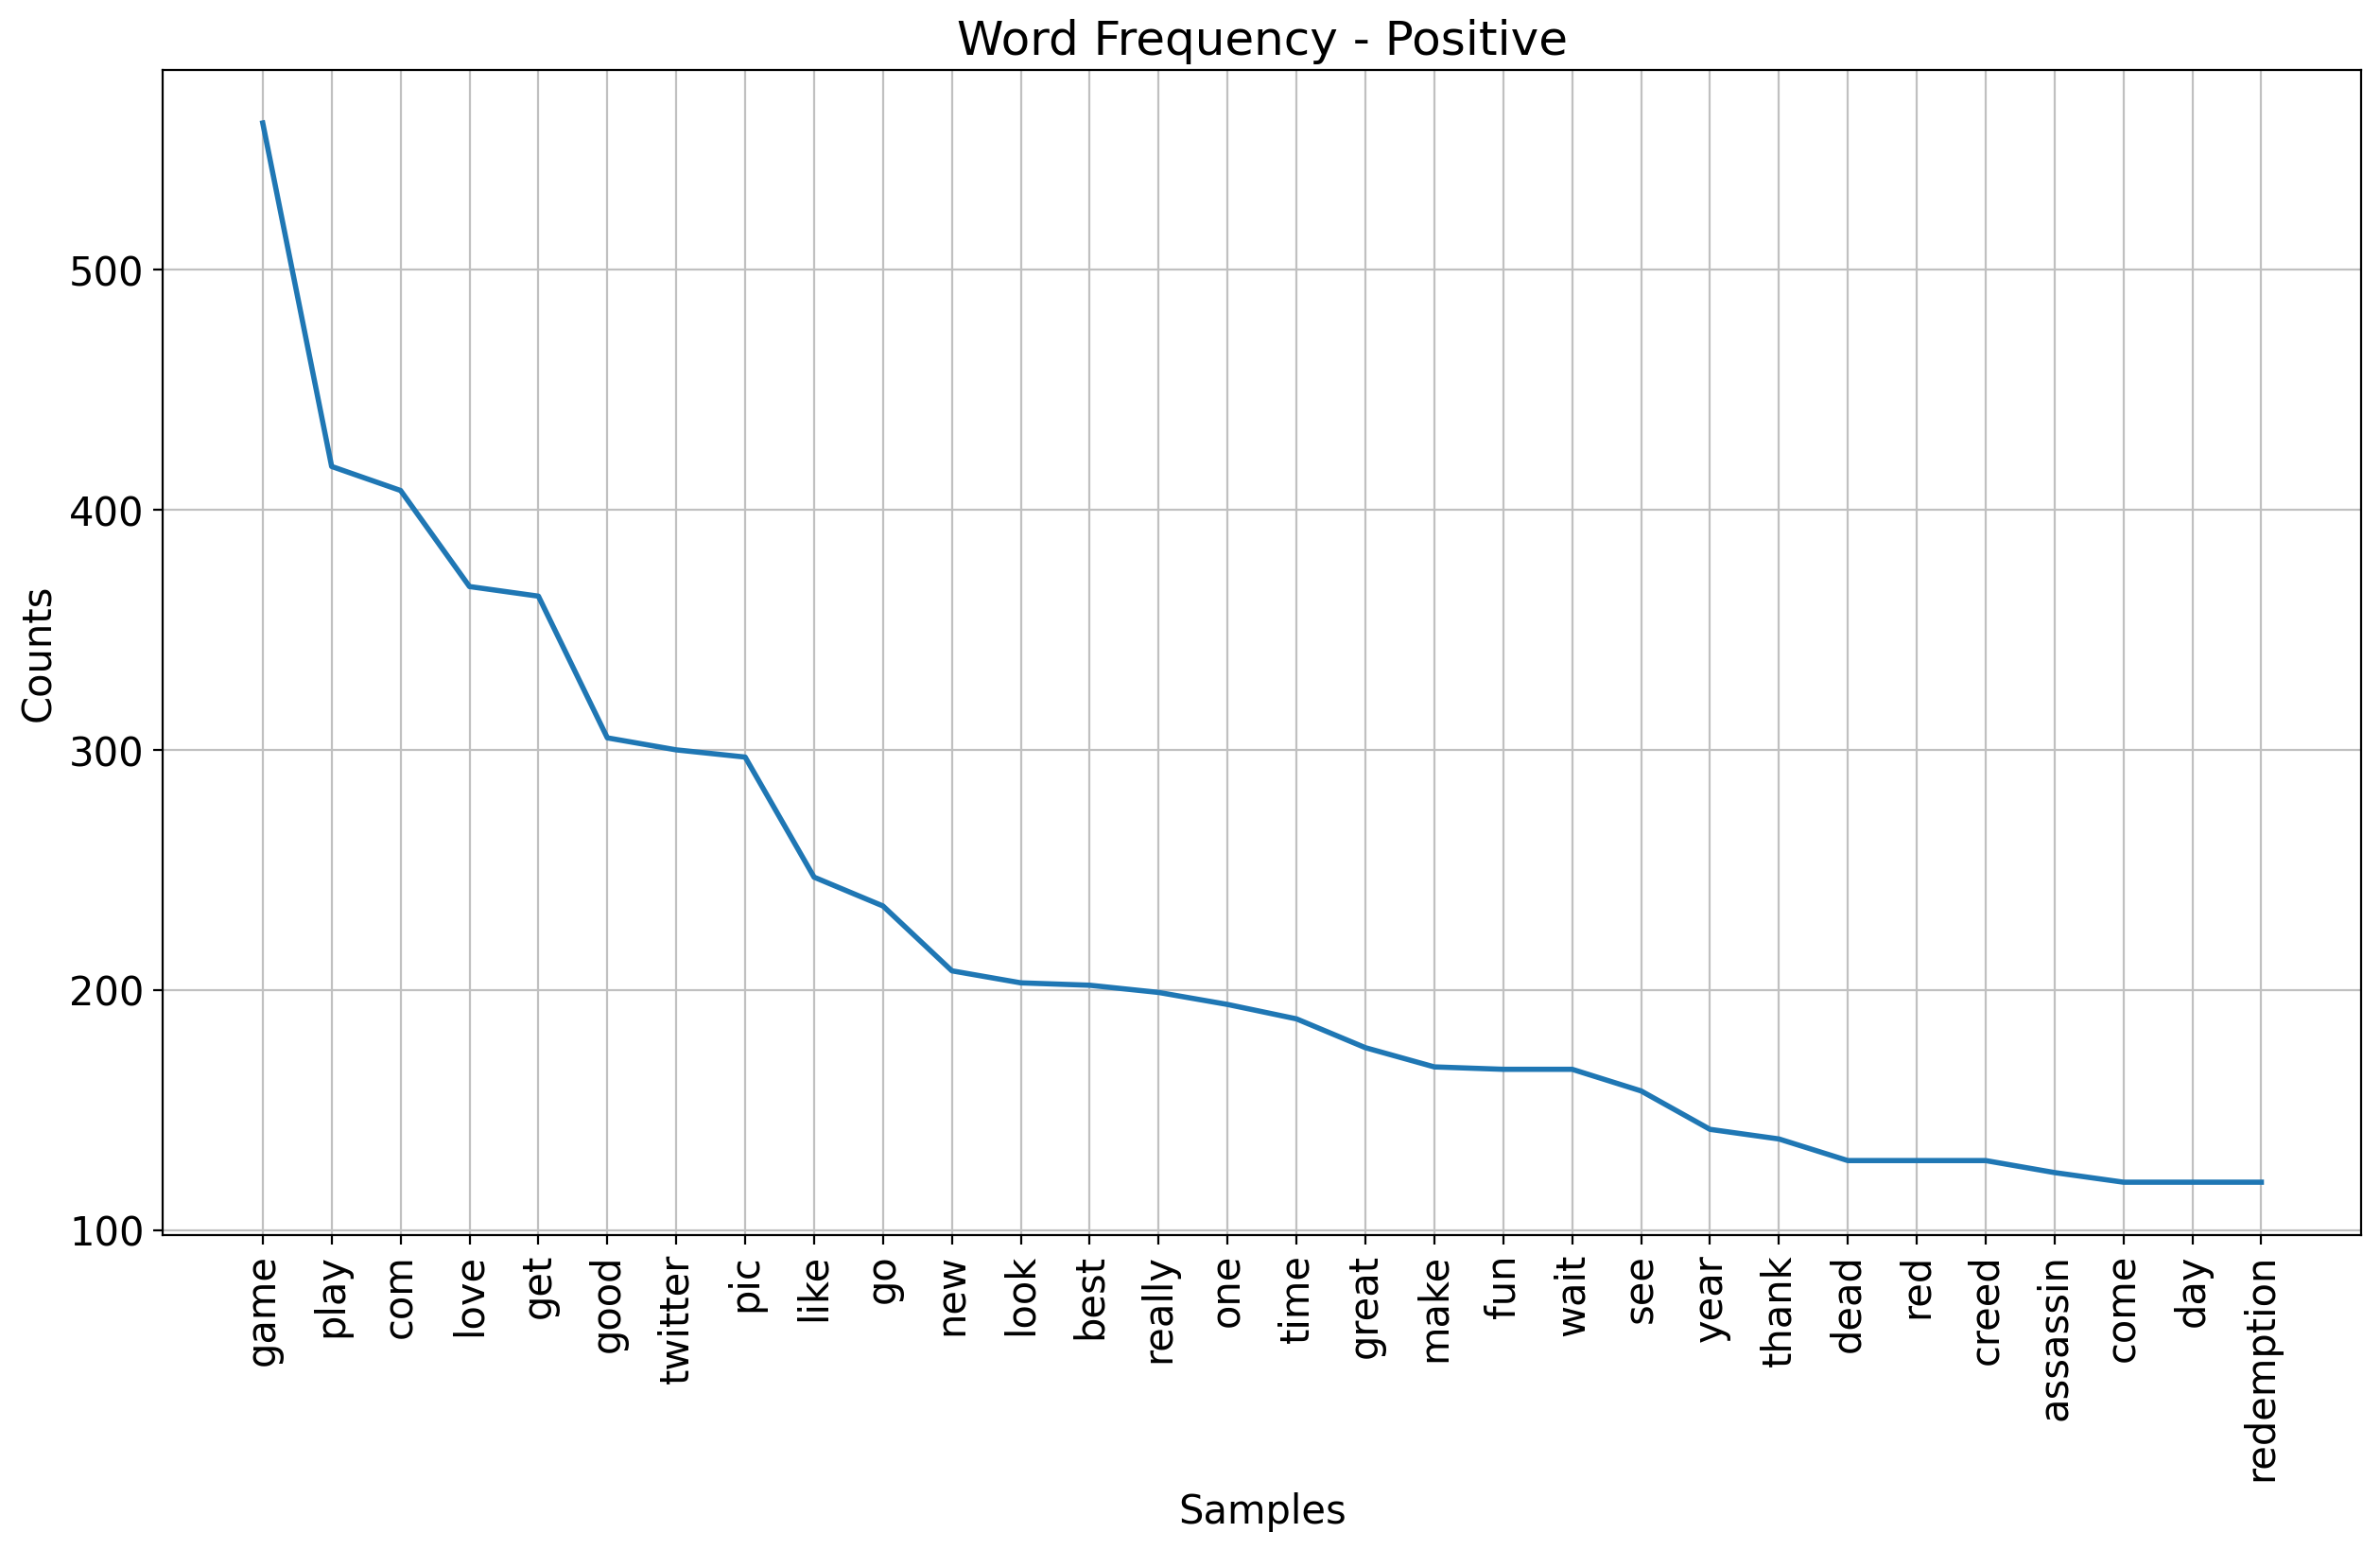

In [58]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (15,8)
plt.rcParams['font.size'] = 15
freq.plot(30, cumulative=False, title='Word Frequency - Positive')

### Word Cloud Visualization

In [59]:
#### collocations = False

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

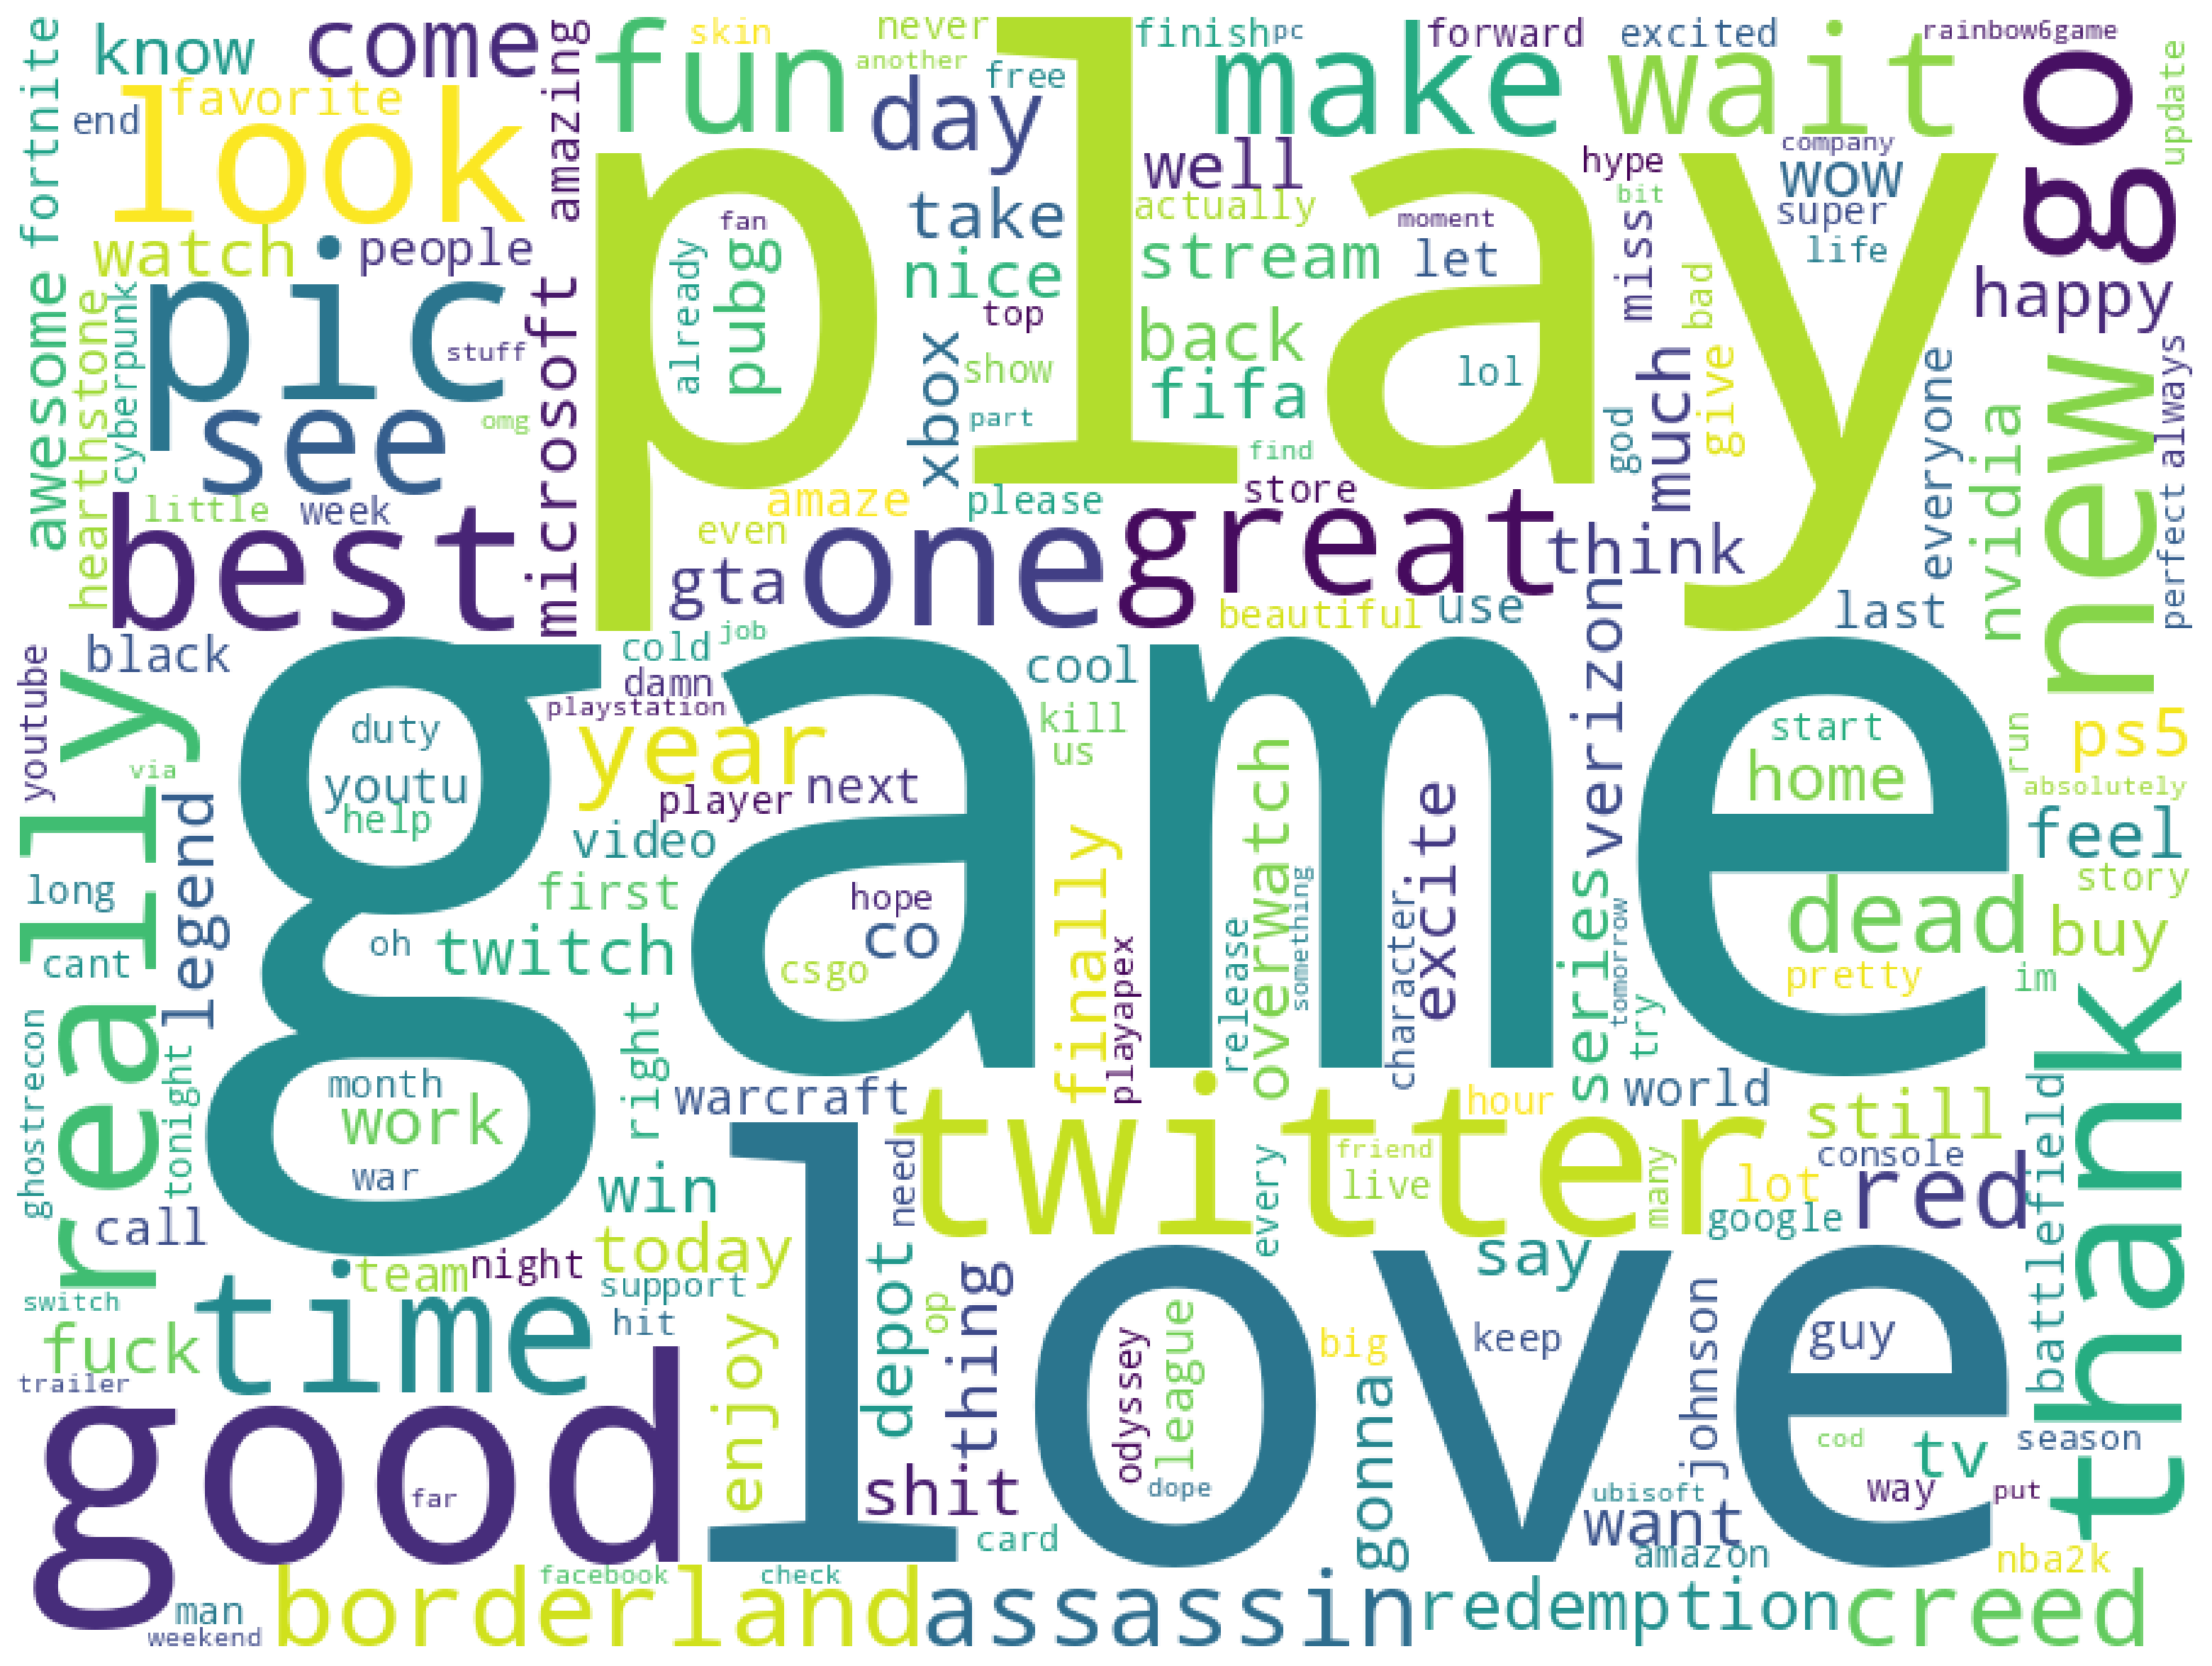

In [60]:
# collocations = False
from wordcloud import WordCloud

cloud = WordCloud(width=800, height=600, collocations=False, background_color = 'white').generate(" ".join(lemmatized_word))
plt.figure(figsize=(20,15))
plt.imshow(cloud)
plt.axis('off')

#### collocations = True

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

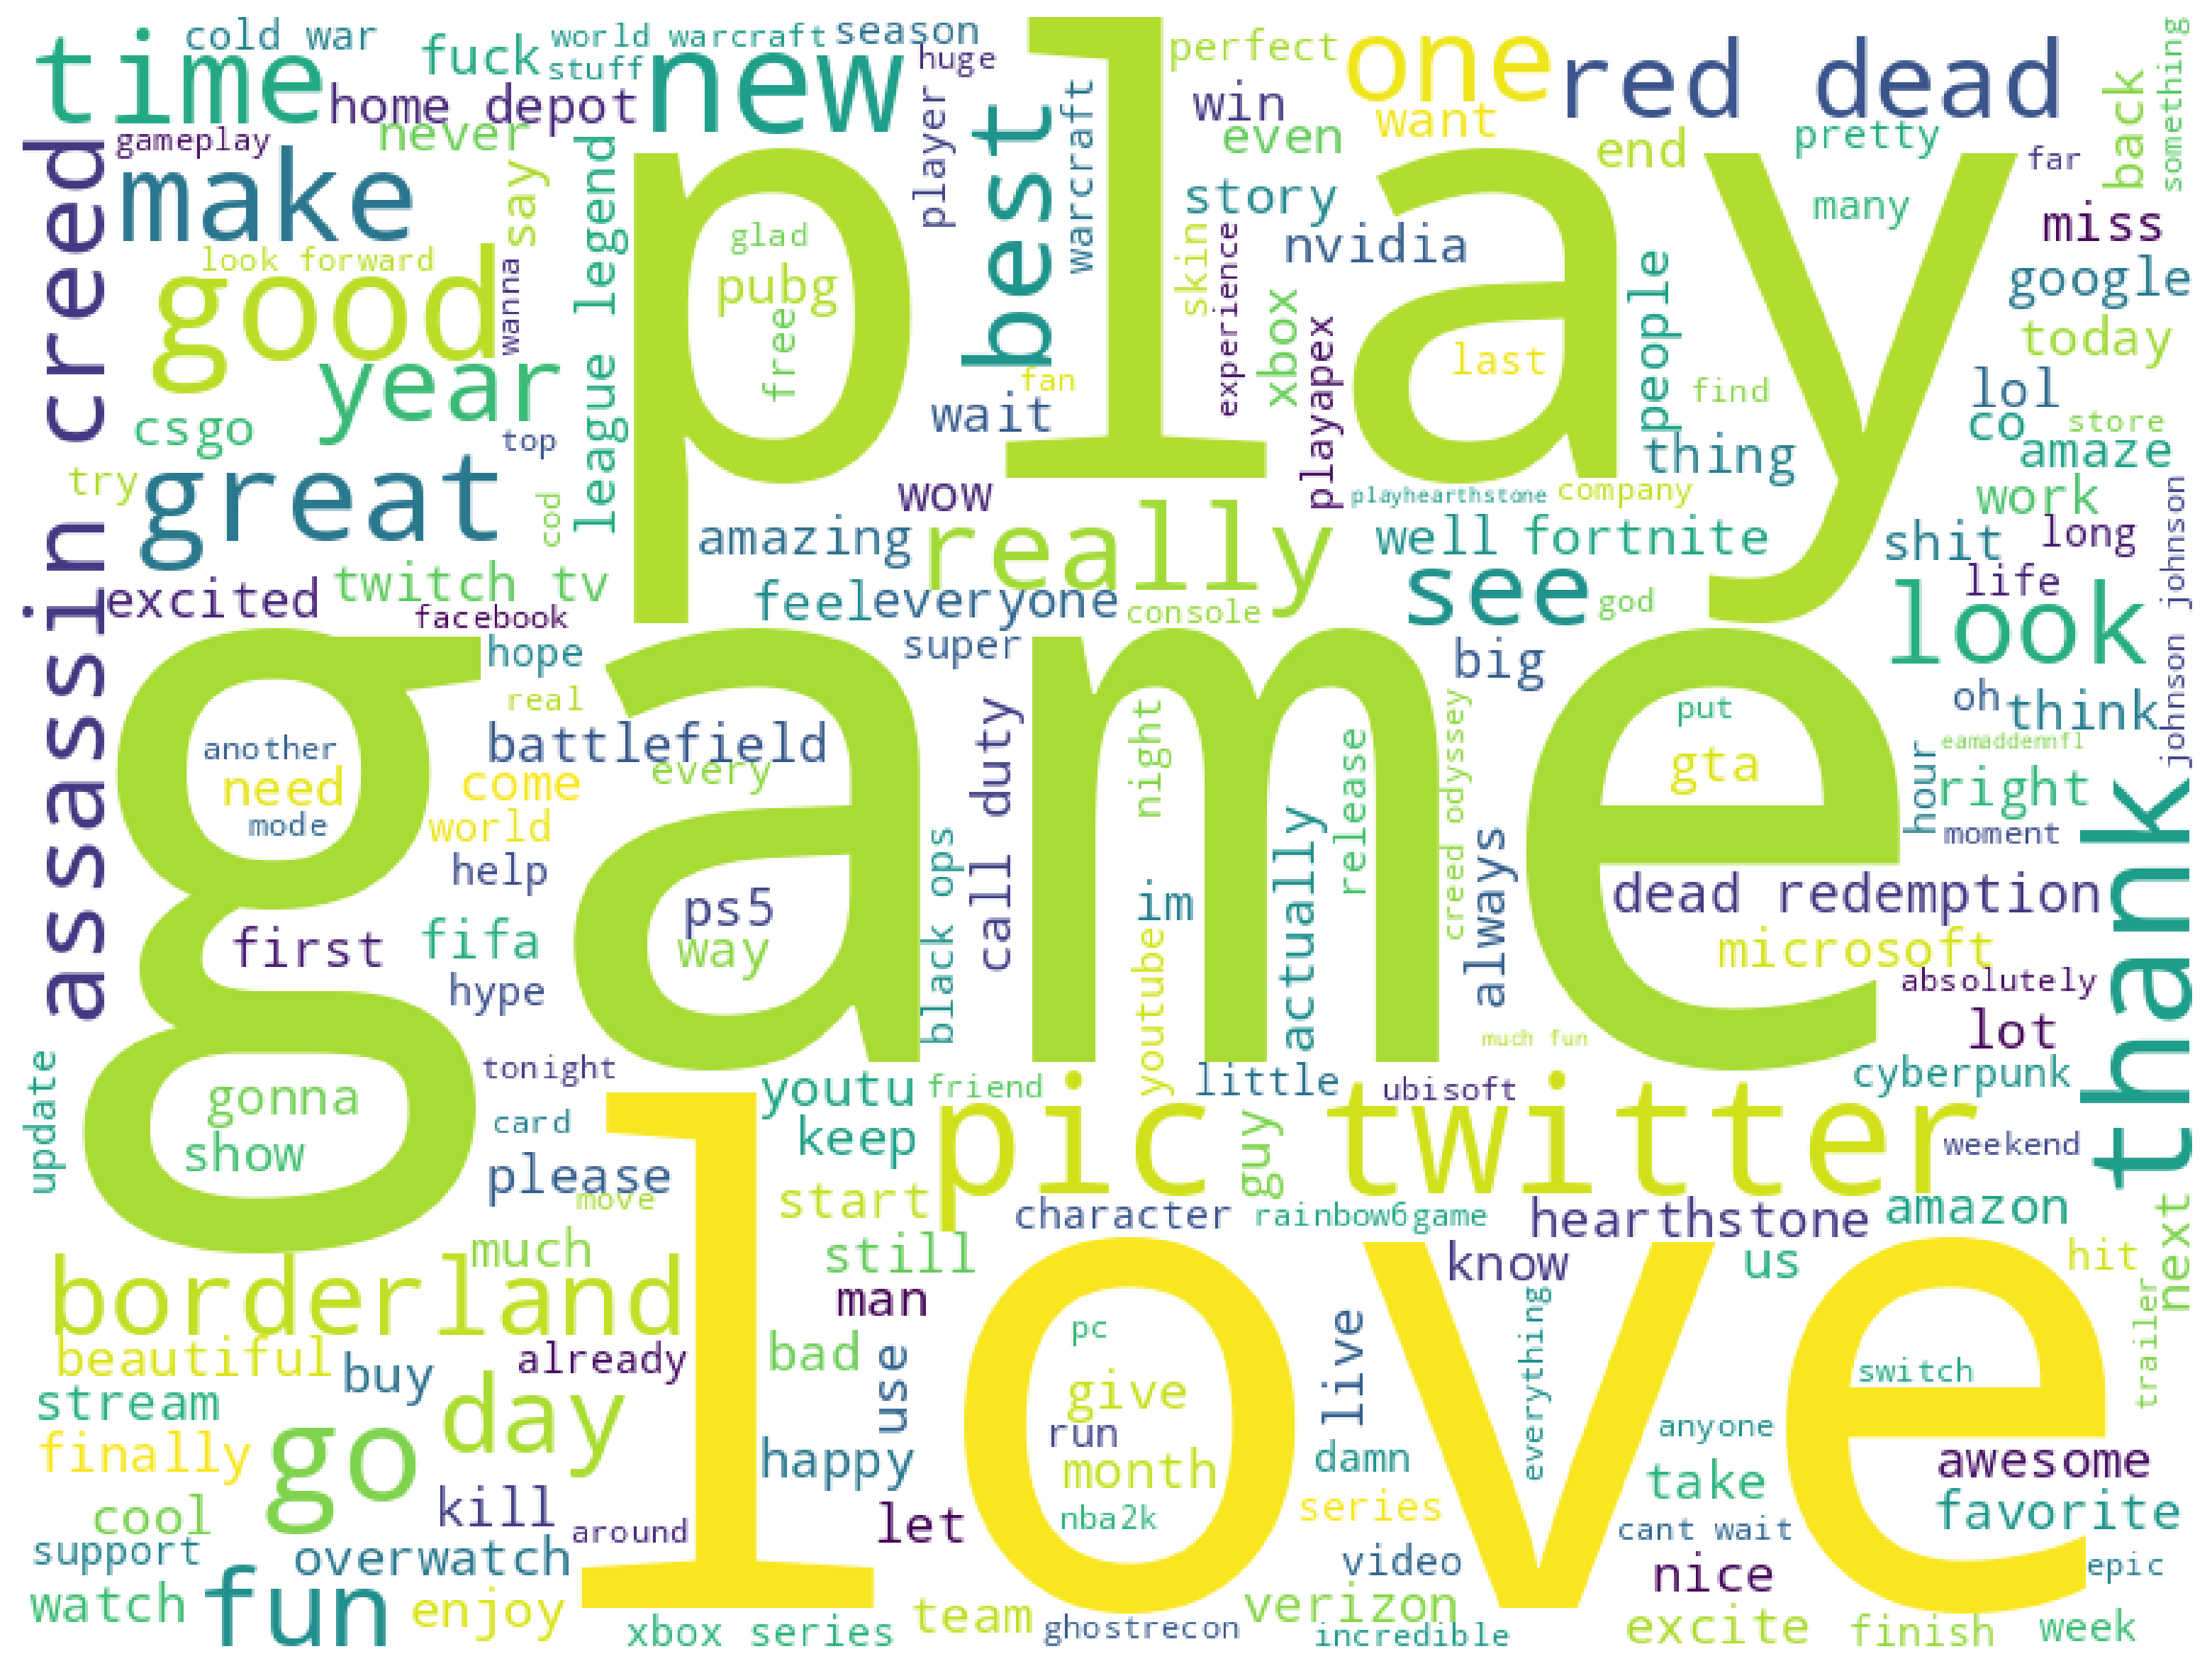

In [61]:
# collocations = True
from wordcloud import WordCloud

cloud = WordCloud(width=800, height=600, background_color = 'white').generate(" ".join(lemmatized_word))
plt.figure(figsize=(20,15))
plt.imshow(cloud)
plt.axis('off')

#### Bigram wordcloud

In [62]:
from nltk import bigrams
bgram = bigrams(lemmatized_word)
bgram_list = [x for x in bgram]

In [63]:
from collections import Counter

c = Counter(bgram_list)
print(c.most_common(30))

[(('twitter', 'com'), 294), (('pic', 'twitter'), 288), (('assassin', 'creed'), 122), (('red', 'dead'), 121), (('dead', 'redemption'), 119), (('twitch', 'tv'), 94), (('home', 'depot'), 70), (('http', 'co'), 61), (('league', 'legend'), 47), (('call', 'duty'), 45), (('black', 'ops'), 41), (('xbox', 'series'), 41), (('cold', 'war'), 38), (('look', 'forward'), 33), (('cyberpunk', '2077'), 31), (('johnson', 'johnson'), 30), (('cant', 'wait'), 29), (('creed', 'odyssey'), 27), (('world', 'warcraft'), 26), (('much', 'fun'), 25), (('ops', 'cold'), 24), (('https', 'co'), 23), (('play', 'game'), 23), (('really', 'good'), 20), (('really', 'enjoy'), 20), (('look', 'like'), 19), (('game', 'ever'), 19), (('game', 'play'), 18), (('love', 'game'), 18), (('video', 'game'), 18)]


In [64]:
"_".join(bgram_list[0])

'im_get'

In [65]:
for i in range(0,len(bgram_list)):
    bgram_list[i] = "_".join(bgram_list[i])

In [66]:
Bigram_Freq = nltk.FreqDist(bgram_list)

In [67]:
# bigram wordcloud
from wordcloud import WordCloud

bigram_wordcloud = WordCloud(width=800, height=600, background_color = 'white').generate_from_frequencies(Bigram_Freq)
plt.figure(figsize = (20,15))
plt.imshow(bigram_wordcloud, interpolation = 'bilinear')
plt.axis("off")

Output hidden; open in https://colab.research.google.com to view.

### Neutral

### Text Preprocessing

### Lemmatization

In [68]:
# 품사를 고려한 표제어 추출을 시행합니다.
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

# POS tag
def pos_tagger(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

tokenized_doc = positive_df['text']

total_lemmmatized = []
for tokenized_sentence in tokenized_doc:
    # tokenize the sentence and find the POS tag for each token
    pos_tagged = nltk.pos_tag(tokenized_sentence)
    new_pos_tagged = [special_func(data) for data in pos_tagged]
    # As you may have noticed, the above pos tags are a little confusing.
    # we use our own pos_tagger function to make things simpler to understand.
    wordnet_tagged = list(map(lambda x: (x[0], pos_tagger(x[1])), new_pos_tagged))

    lemmatized_sentence = []
    for word, tag in wordnet_tagged:
        if tag is None:
            # if there is no available tag, append the token as is
            lemmatized_sentence.append(word)
        else:
            # else use the tag to lemmatize the token
            lemmatized_sentence.append(lemmatizer.lemmatize(word, tag))

    total_lemmmatized.append(lemmatized_sentence)

lemmatized_doc = pd.Series(total_lemmmatized)
lemmatized_doc[:5]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,0
0,"[im, get, on, borderland, and, i, will, murder..."
1,"[so, i, spend, a, few, hour, make, something, ..."
2,"[that, be, the, first, borderlands, session, i..."
3,"[we, finish, borderland, 3, finally, yas, than..."
4,"[go, to, finish, up, borderland, 2, today, i, ..."


### Stopwords Removal

In [69]:
# Lemmatization Considering Parts of Speech (POS)
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

# POS tag
def pos_tagger(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

tokenized_doc = neutral_df['text']

total_lemmmatized = []
for tokenized_sentence in tokenized_doc:
    # tokenize the sentence and find the POS tag for each token
    pos_tagged = nltk.pos_tag(tokenized_sentence)
    new_pos_tagged = [special_func(data) for data in pos_tagged]
    # As you may have noticed, the above pos tags are a little confusing.
    # we use our own pos_tagger function to make things simpler to understand.
    wordnet_tagged = list(map(lambda x: (x[0], pos_tagger(x[1])), new_pos_tagged))

    lemmatized_sentence = []
    for word, tag in wordnet_tagged:
        if tag is None:
            # if there is no available tag, append the token as is
            lemmatized_sentence.append(word)
        else:
            # else use the tag to lemmatize the token
            lemmatized_sentence.append(lemmatizer.lemmatize(word, tag))

    total_lemmmatized.append(lemmatized_sentence)

lemmatized_doc = pd.Series(total_lemmmatized)
lemmatized_doc[:5]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,0
0,"[rock, hard, la, varlope, rare, powerful, hand..."
1,"[check, out, this, epic, streamer]"
2,"[blame, sight, for, tardiness, a, little, bit,..."
3,[]
4,"[one, of, our, own, profzeroo, be, live, w, bo..."


In [70]:
lemmatized_doc[:5]

,0
0,"[rock, hard, la, varlope, rare, powerful, hand..."
1,"[check, out, this, epic, streamer]"
2,"[blame, sight, for, tardiness, a, little, bit,..."
3,[]
4,"[one, of, our, own, profzeroo, be, live, w, bo..."


In [71]:
from nltk.corpus import stopwords
nltk.download('stopwords')

# Retrieve the list of stopwords from NLTK
stop_words = set(stopwords.words('english'))

# Remove stopwords
lemmatized_doc = [[word for word in doc if word.lower() not in stop_words and len(word) > 1] for doc in lemmatized_doc]

print(lemmatized_doc)

[['rock', 'hard', 'la', 'varlope', 'rare', 'powerful', 'handsome', 'jackpot', 'borderlands', 'xbox', 'dlvr', 'rmtrgf'], ['check', 'epic', 'streamer'], ['blame', 'sight', 'tardiness', 'little', 'bit', 'borderland', 'get', 'call', 'early', 'work', 'tomorrow', 'make', 'time', 'sorry', 'love', 'twitch', 'tv', 'punnisenpai'], [], ['one', 'profzeroo', 'live', 'borderlands', 'catch', 'buff', 'ly', '2wmmip5', 'say', 'streamer', 'shout', 'chat', 'chance', 'come', 'streamer', 'shout', 'shout'], ['hate', 'easy', 'mayhem', 'modifier', 'event', 'mayhem', 'win', 'last', 'forever', 'fun', 'game', 'since', 'add', 'horrible', 'modifier', 'borderlands', 'please', 'give', 'option', 'play', 'mayhem', '10', 'turn', 'modifier', 'pls'], ['already', 'love', 'bleed', 'edge', 'clever', 'game', 'cross', 'overwatch', 'borderland', 'domination', 'game', 'mode', 'cool'], ['reason', 'laptop', 'run', 'borderlands', 'war', 'thunder', 'warframe', 'high', 'setting', 'moment', 'even', 'try', 'even', 'launch', 'csgo', 'en

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [72]:
# Detokenization (Reversing the Tokenization Process)
detokenized_doc = []
for i in range(len(lemmatized_doc)):
    t = ' '.join(lemmatized_doc[i])
    detokenized_doc.append(t)
detokenized_doc[:5]

['rock hard la varlope rare powerful handsome jackpot borderlands xbox dlvr rmtrgf',
 'check epic streamer',
 'blame sight tardiness little bit borderland get call early work tomorrow make time sorry love twitch tv punnisenpai',
 '',
 'one profzeroo live borderlands catch buff ly 2wmmip5 say streamer shout chat chance come streamer shout shout']

In [73]:
lemmatized_text = detokenized_doc.copy()

In [74]:
detokenized_doc = ' '.join(detokenized_doc)
lemmatized_word = detokenized_doc.split(' ')
# Remove Empty Lists
lemmatized_word = [v for v in lemmatized_word if v]

In [75]:
lemmatized_word

['rock',
 'hard',
 'la',
 'varlope',
 'rare',
 'powerful',
 'handsome',
 'jackpot',
 'borderlands',
 'xbox',
 'dlvr',
 'rmtrgf',
 'check',
 'epic',
 'streamer',
 'blame',
 'sight',
 'tardiness',
 'little',
 'bit',
 'borderland',
 'get',
 'call',
 'early',
 'work',
 'tomorrow',
 'make',
 'time',
 'sorry',
 'love',
 'twitch',
 'tv',
 'punnisenpai',
 'one',
 'profzeroo',
 'live',
 'borderlands',
 'catch',
 'buff',
 'ly',
 '2wmmip5',
 'say',
 'streamer',
 'shout',
 'chat',
 'chance',
 'come',
 'streamer',
 'shout',
 'shout',
 'hate',
 'easy',
 'mayhem',
 'modifier',
 'event',
 'mayhem',
 'win',
 'last',
 'forever',
 'fun',
 'game',
 'since',
 'add',
 'horrible',
 'modifier',
 'borderlands',
 'please',
 'give',
 'option',
 'play',
 'mayhem',
 '10',
 'turn',
 'modifier',
 'pls',
 'already',
 'love',
 'bleed',
 'edge',
 'clever',
 'game',
 'cross',
 'overwatch',
 'borderland',
 'domination',
 'game',
 'mode',
 'cool',
 'reason',
 'laptop',
 'run',
 'borderlands',
 'war',
 'thunder',
 'warfram

### Top 30 Most Frequent Words

In [76]:
from nltk import FreqDist

freq = FreqDist(lemmatized_word)
freq.most_common(30)

[('com', 757),
 ('johnson', 350),
 ('co', 320),
 ('game', 311),
 ('get', 296),
 ('play', 262),
 ('amazon', 233),
 ('twitter', 215),
 ('http', 207),
 ('pic', 190),
 ('go', 187),
 ('twitch', 179),
 ('tv', 174),
 ('win', 167),
 ('like', 162),
 ('facebook', 158),
 ('make', 156),
 ('google', 154),
 ('2020', 152),
 ('new', 148),
 ('microsoft', 147),
 ('one', 145),
 ('nvidia', 132),
 ('dead', 132),
 ('good', 127),
 ('red', 126),
 ('see', 120),
 ('news', 115),
 ('xbox', 114),
 ('love', 113)]

In [77]:
df_fq = pd.DataFrame.from_dict(freq, orient='index')
df_fq.columns = ['Frequency']
df_fq.index.name = 'keyword'

<Axes: title={'center': 'Word Frequency - Neutral'}, xlabel='Samples', ylabel='Counts'>

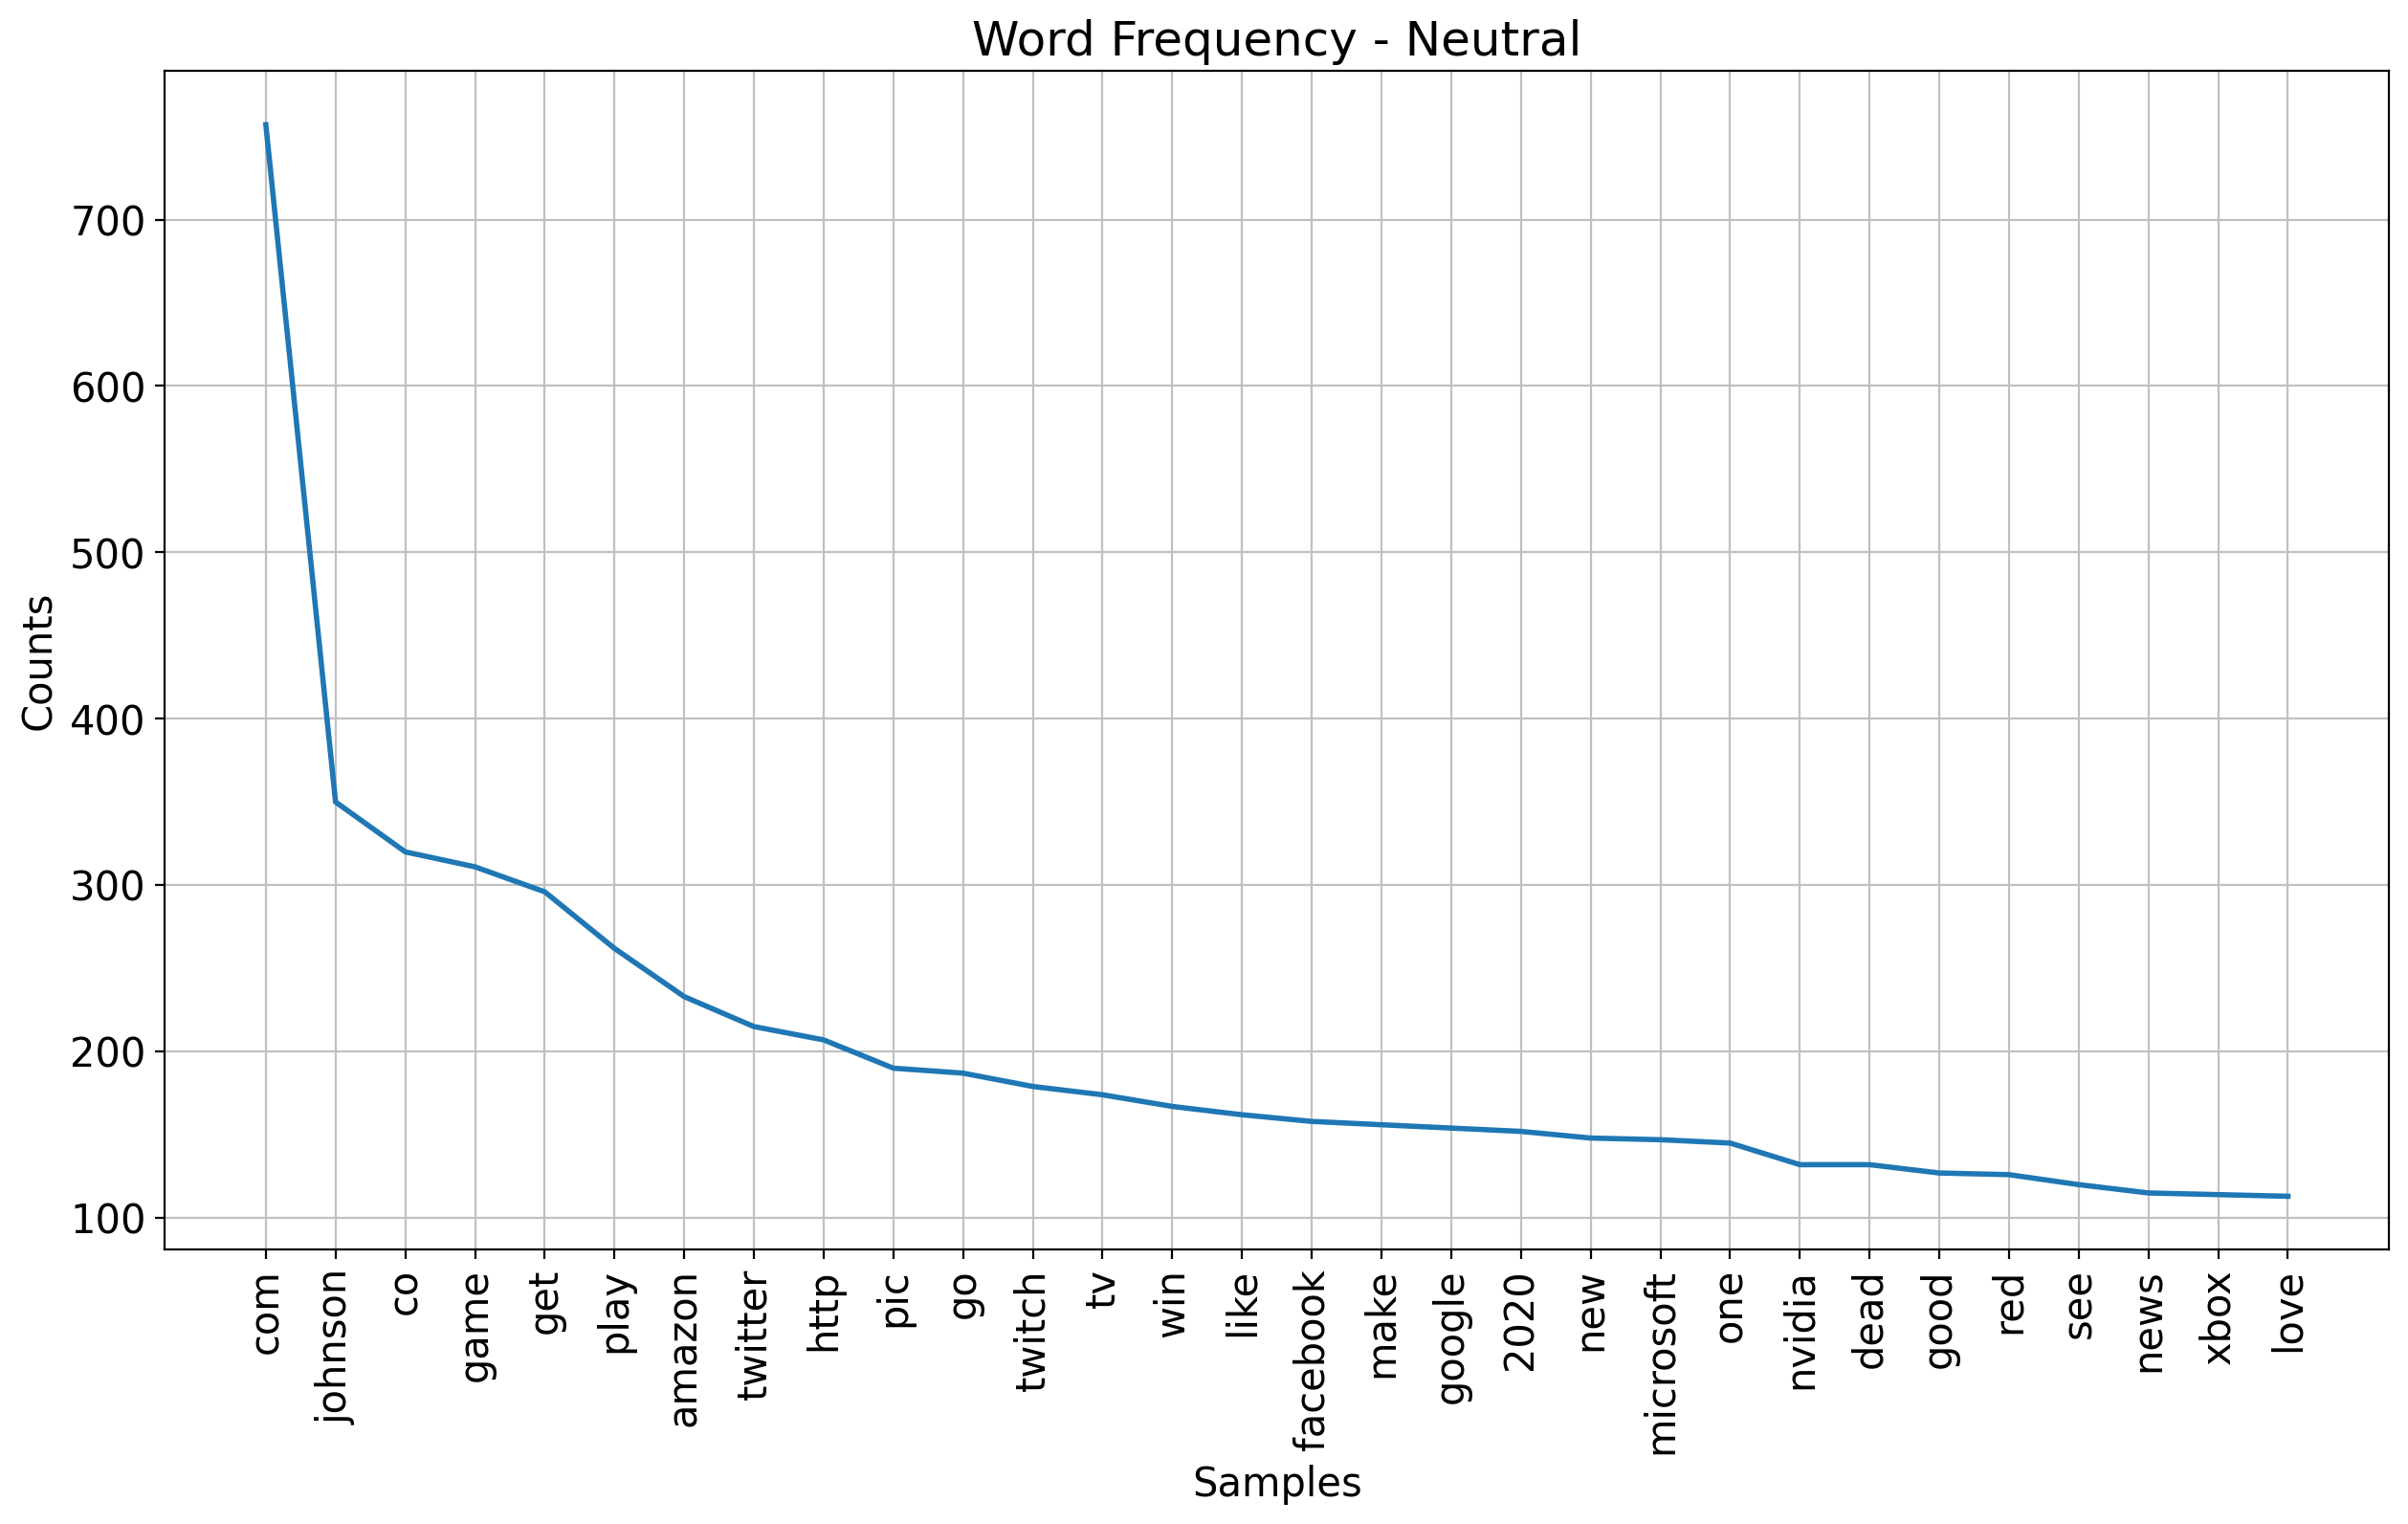

In [78]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (15,8)
plt.rcParams['font.size'] = 15
freq.plot(30, cumulative=False, title='Word Frequency - Neutral')

### Word Cloud Visualization

#### collocations = False

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

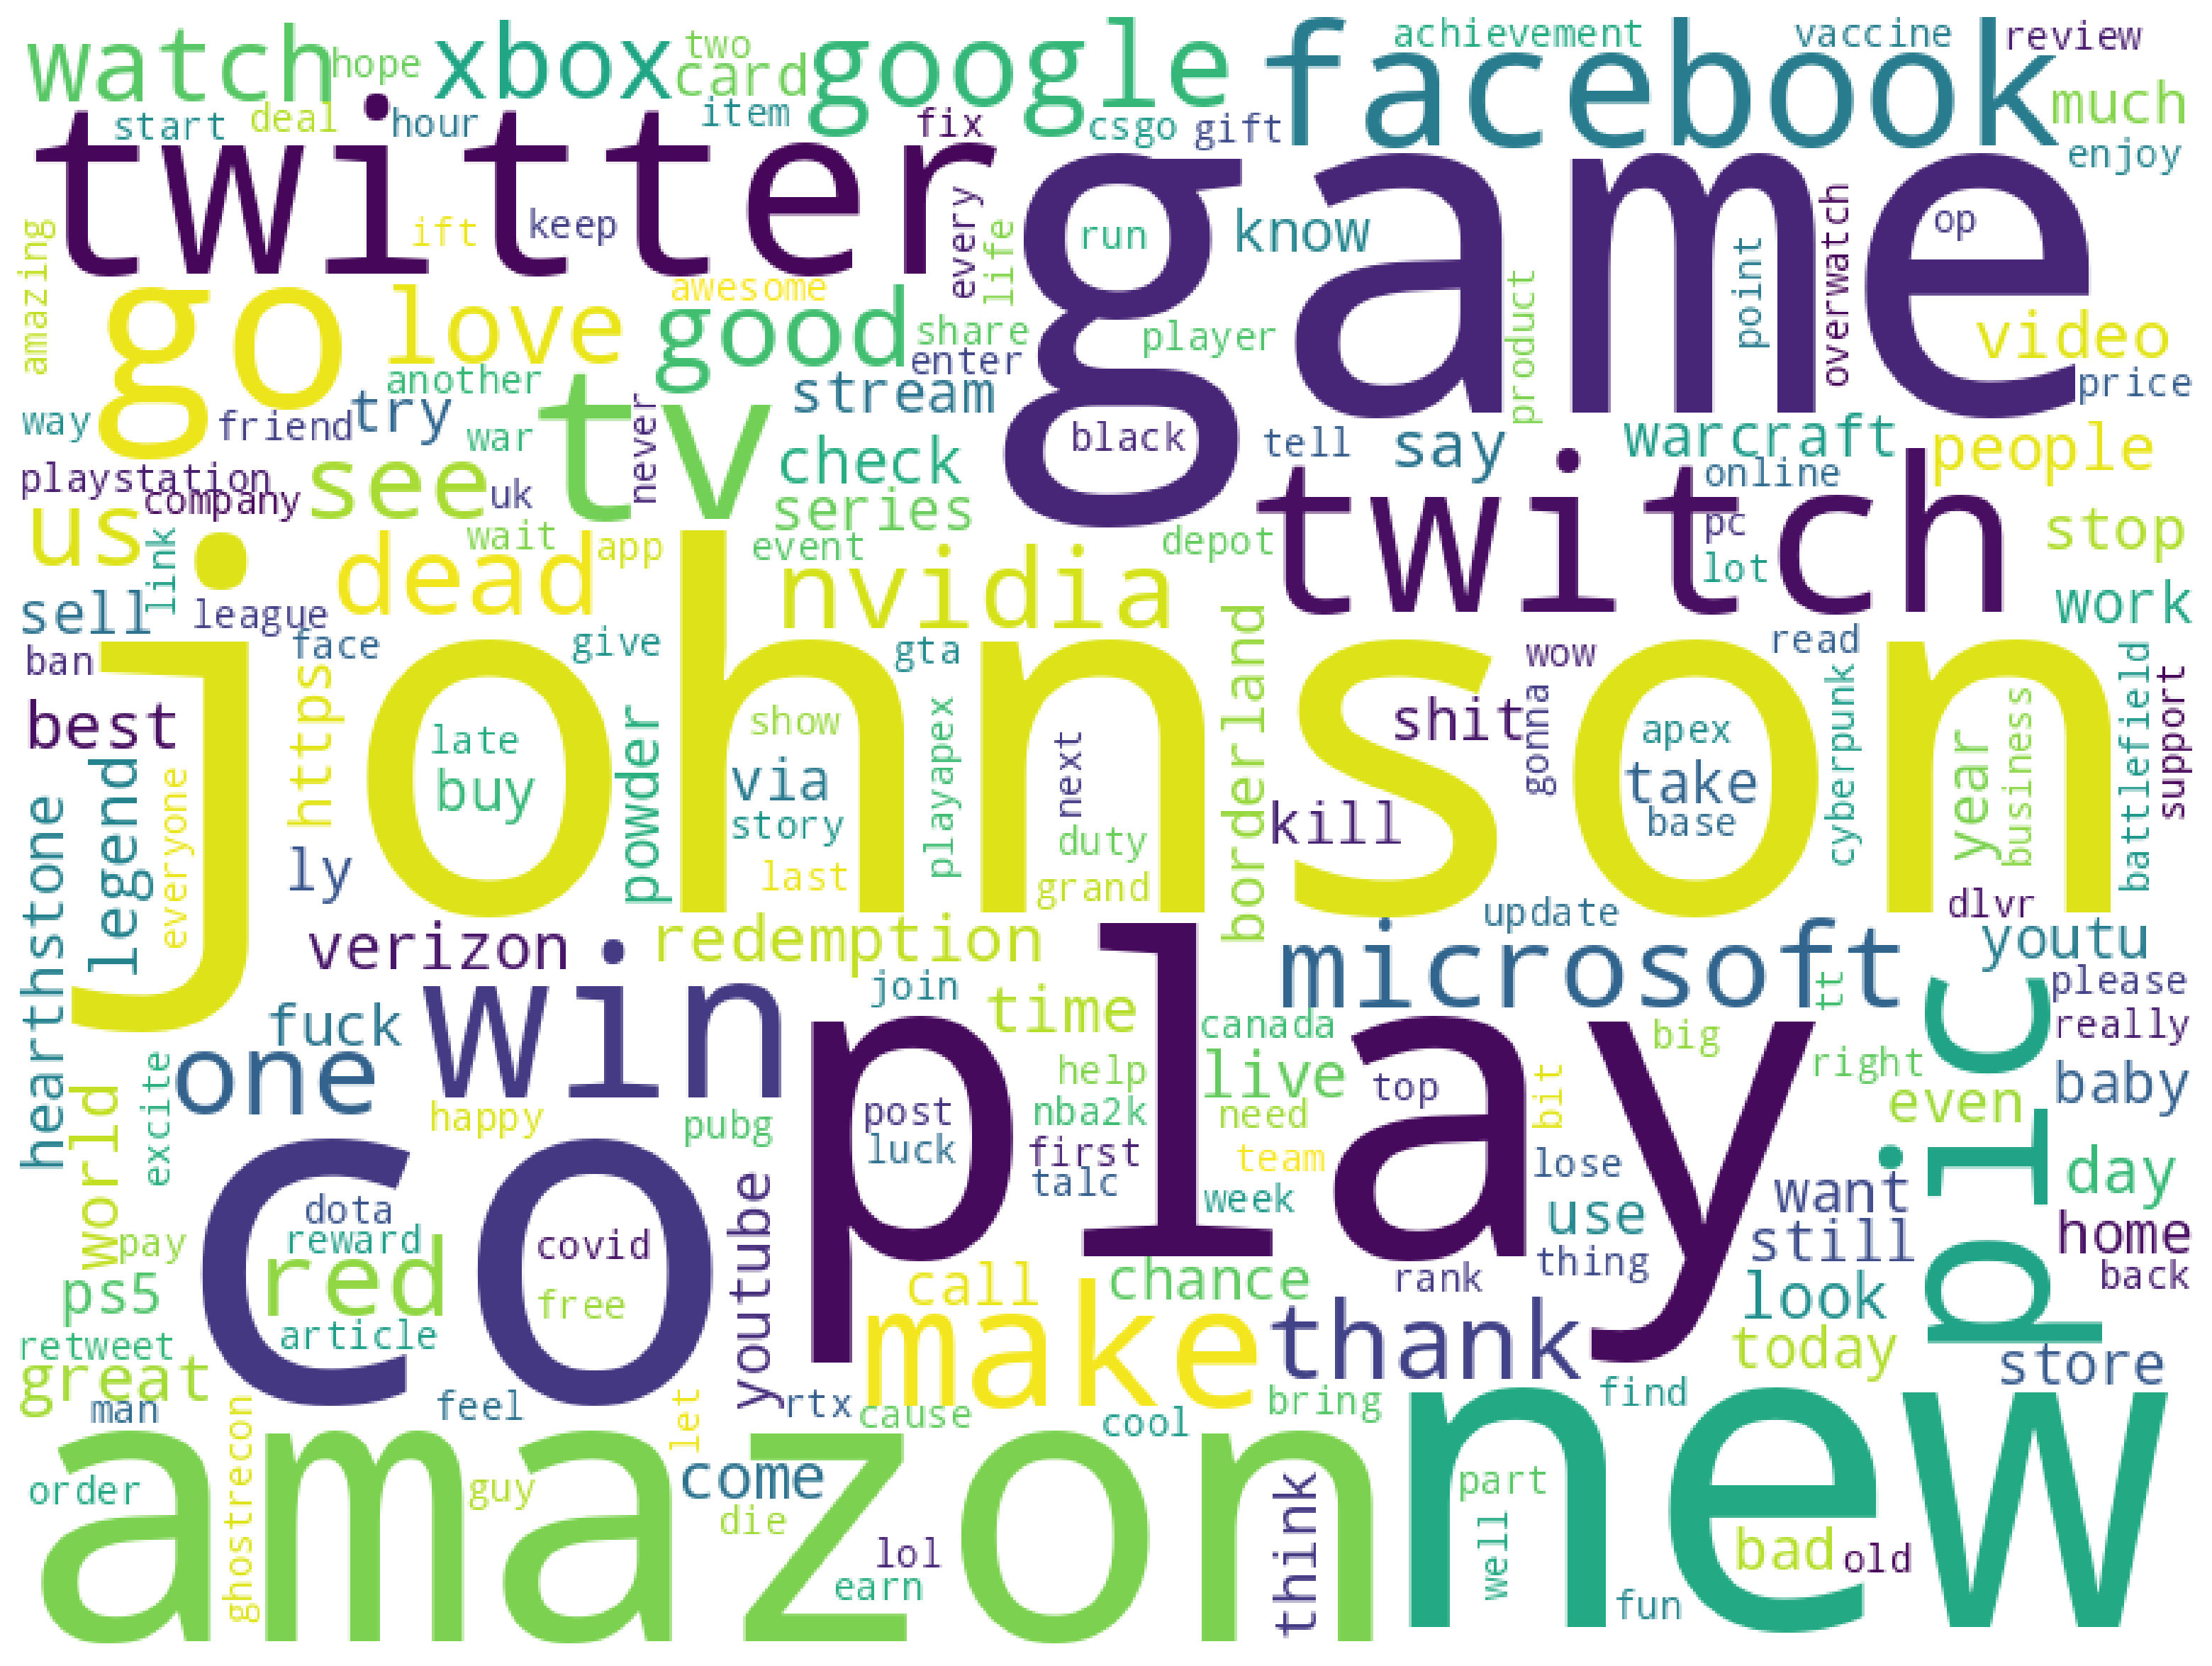

In [79]:
# collocations = False
from wordcloud import WordCloud

cloud = WordCloud(width=800, height=600, collocations=False, background_color = 'white').generate(" ".join(lemmatized_word))
plt.figure(figsize=(20,15))
plt.imshow(cloud)
plt.axis('off')

#### collocations = True

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

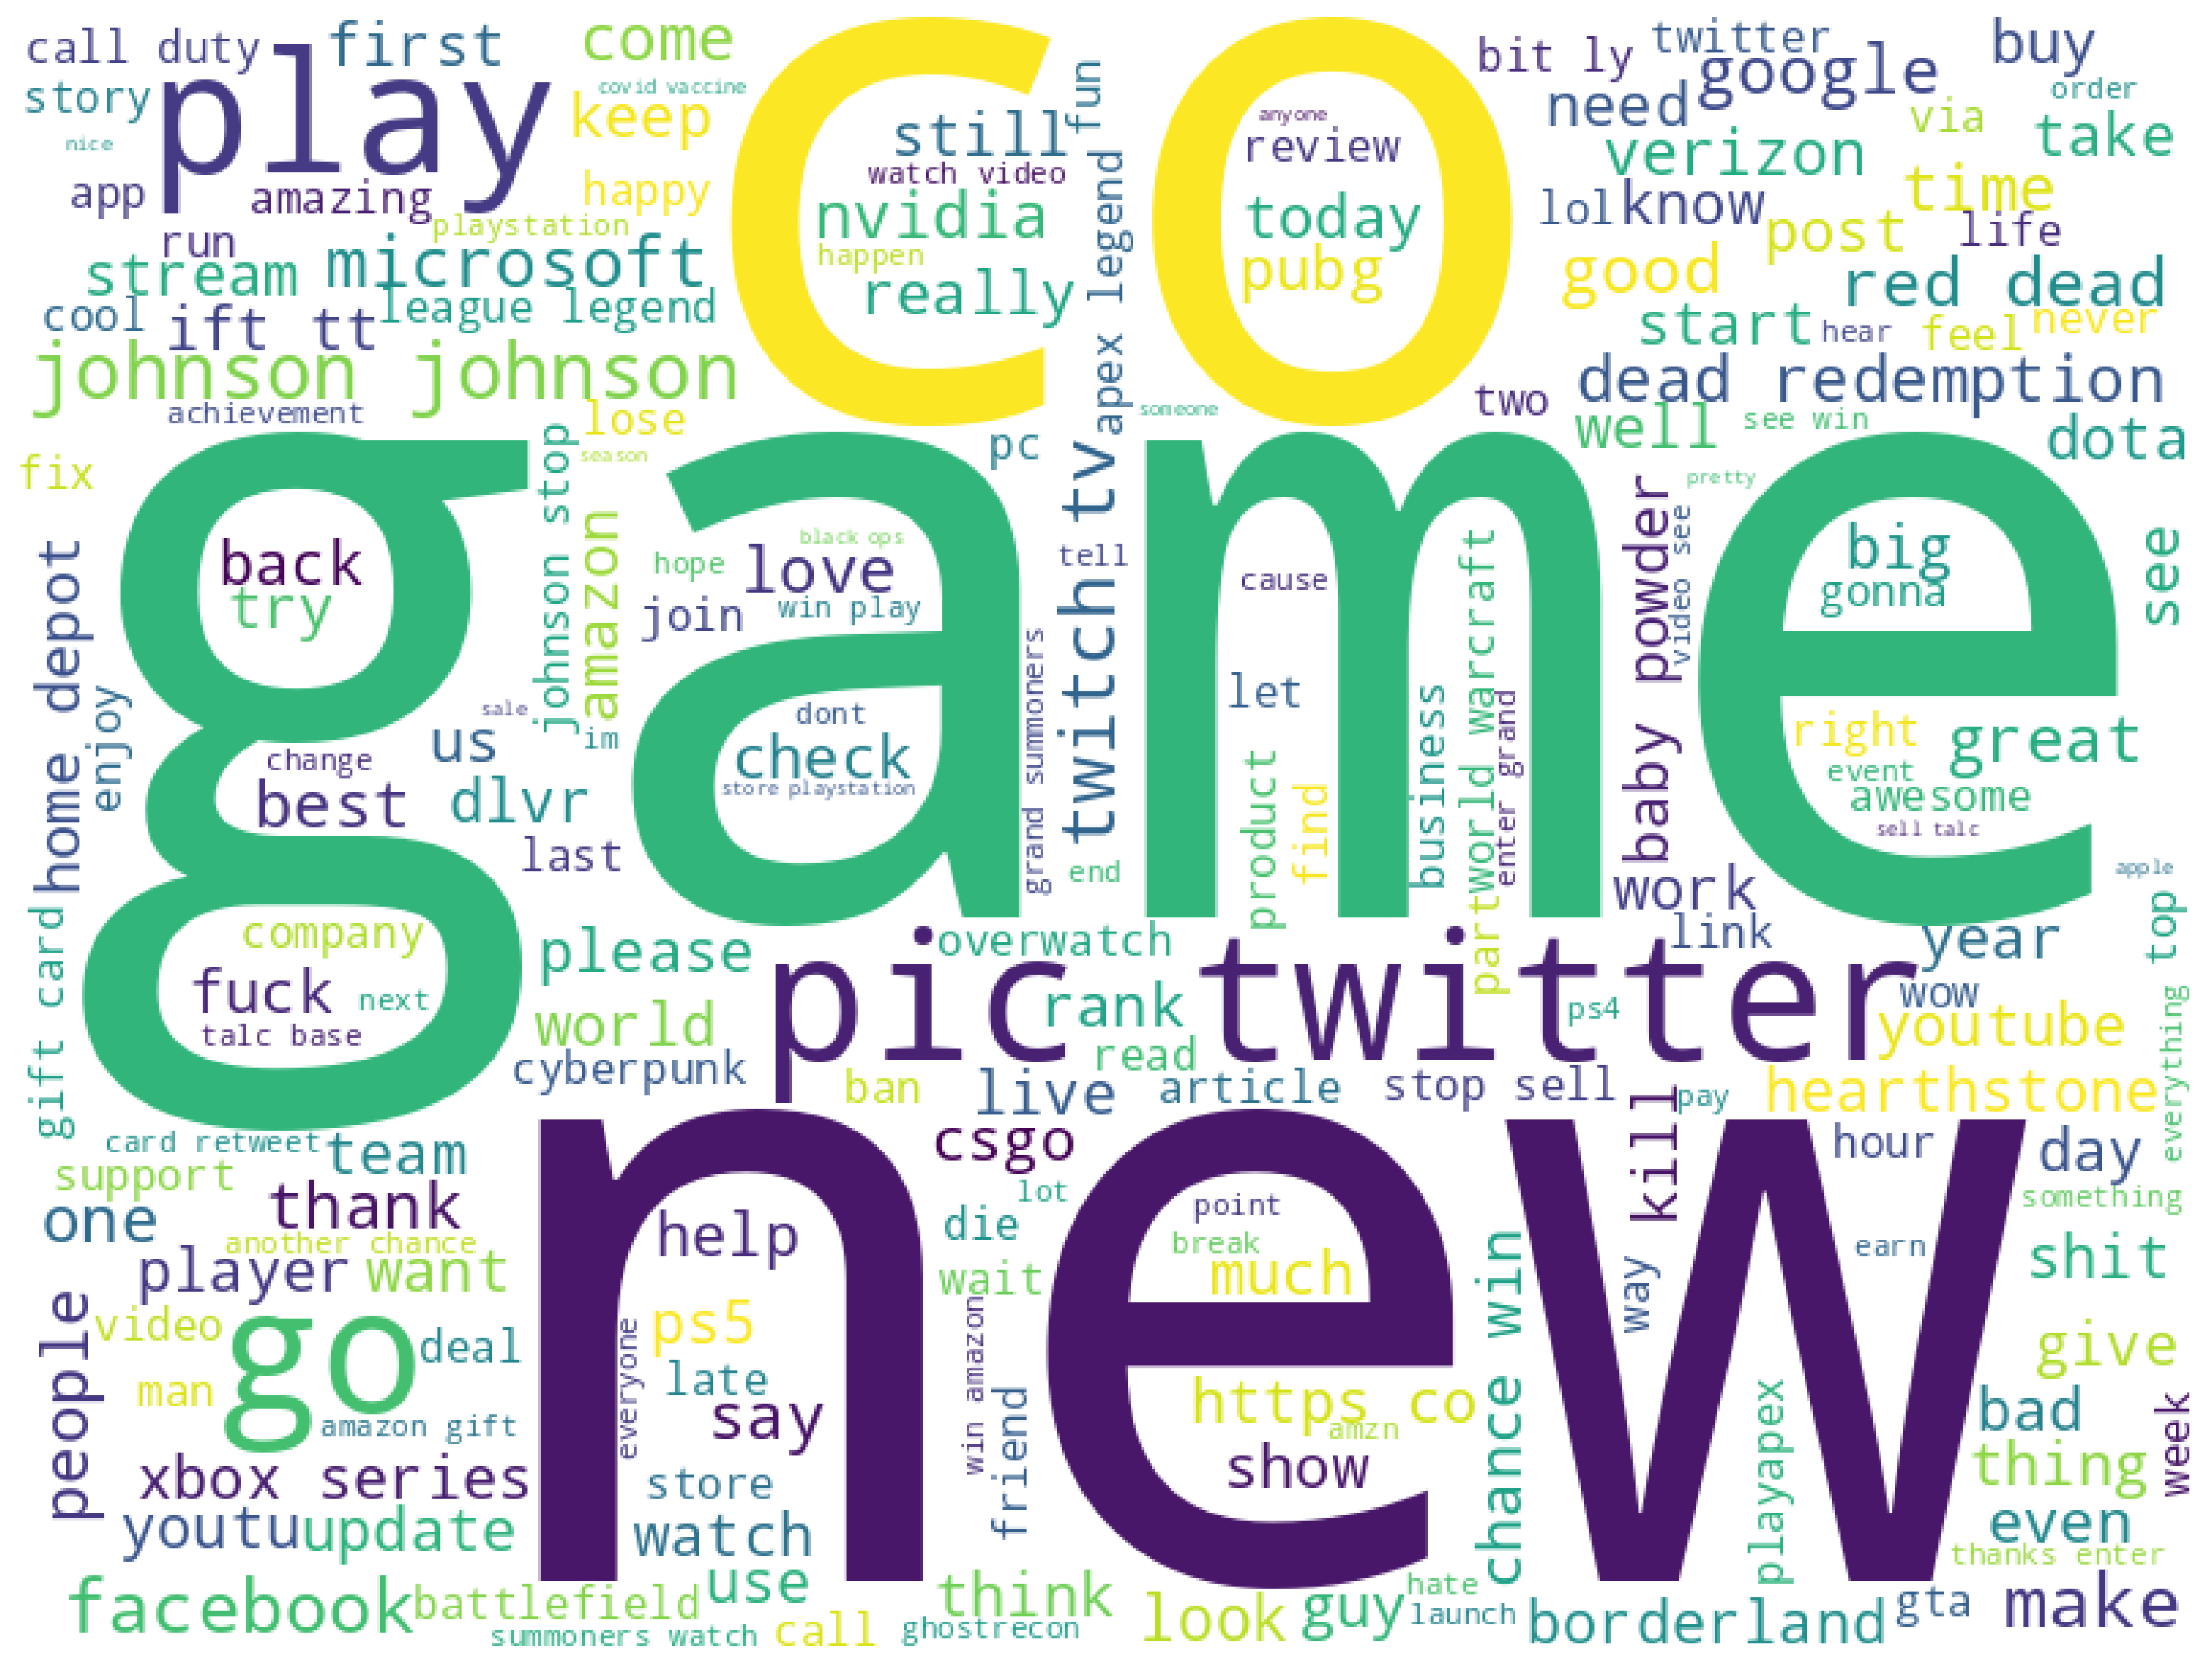

In [80]:
# collocations = True
from wordcloud import WordCloud

cloud = WordCloud(width=800, height=600, background_color = 'white').generate(" ".join(lemmatized_word))
plt.figure(figsize=(20,15))
plt.imshow(cloud)
plt.axis('off')

#### Bigram wordcloud

In [81]:
from nltk import bigrams
bgram = bigrams(lemmatized_word)
bgram_list = [x for x in bgram]

In [82]:
from collections import Counter

c = Counter(bgram_list)
print(c.most_common(30))

[(('http', 'co'), 206), (('twitter', 'com'), 196), (('pic', 'twitter'), 185), (('johnson', 'johnson'), 165), (('twitch', 'tv'), 152), (('red', 'dead'), 119), (('dead', 'redemption'), 112), (('https', 'co'), 77), (('com', '2020'), 72), (('xbox', 'series'), 58), (('baby', 'powder'), 56), (('ift', 'tt'), 50), (('chance', 'win'), 50), (('home', 'depot'), 50), (('cyberpunk', '2077'), 45), (('league', 'legend'), 44), (('johnson', 'stop'), 41), (('bit', 'ly'), 40), (('stop', 'sell'), 38), (('call', 'duty'), 37), (('world', 'warcraft'), 37), (('covid', '19'), 35), (('youtube', 'com'), 30), (('gift', 'card'), 30), (('amazon', 'gift'), 29), (('another', 'chance'), 27), (('com', 'news'), 27), (('talc', 'base'), 27), (('thanks', 'enter'), 26), (('enter', 'grand'), 26)]


In [83]:
"_".join(bgram_list[0])

'rock_hard'

In [84]:
for i in range(0,len(bgram_list)):
    bgram_list[i] = "_".join(bgram_list[i])

In [85]:
Bigram_Freq = nltk.FreqDist(bgram_list)

In [86]:
# bigram wordcloud
from wordcloud import WordCloud

bigram_wordcloud = WordCloud(width=800, height=600, background_color = 'white').generate_from_frequencies(Bigram_Freq)
plt.figure(figsize = (20,15))
plt.imshow(bigram_wordcloud, interpolation = 'bilinear')
plt.axis("off")

Output hidden; open in https://colab.research.google.com to view.

### Negative

### Text Preprocessing

### Lemmatization

In [87]:
# 품사를 고려한 표제어 추출을 시행합니다.
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

# POS tag
def pos_tagger(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

tokenized_doc = positive_df['text']

total_lemmmatized = []
for tokenized_sentence in tokenized_doc:
    # tokenize the sentence and find the POS tag for each token
    pos_tagged = nltk.pos_tag(tokenized_sentence)
    new_pos_tagged = [special_func(data) for data in pos_tagged]
    # As you may have noticed, the above pos tags are a little confusing.
    # we use our own pos_tagger function to make things simpler to understand.
    wordnet_tagged = list(map(lambda x: (x[0], pos_tagger(x[1])), new_pos_tagged))

    lemmatized_sentence = []
    for word, tag in wordnet_tagged:
        if tag is None:
            # if there is no available tag, append the token as is
            lemmatized_sentence.append(word)
        else:
            # else use the tag to lemmatize the token
            lemmatized_sentence.append(lemmatizer.lemmatize(word, tag))

    total_lemmmatized.append(lemmatized_sentence)

lemmatized_doc = pd.Series(total_lemmmatized)
lemmatized_doc[:5]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,0
0,"[im, get, on, borderland, and, i, will, murder..."
1,"[so, i, spend, a, few, hour, make, something, ..."
2,"[that, be, the, first, borderlands, session, i..."
3,"[we, finish, borderland, 3, finally, yas, than..."
4,"[go, to, finish, up, borderland, 2, today, i, ..."


### Stopwords Removal

In [88]:
# Lemmatization Considering Parts of Speech (POS)
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

# POS tag
def pos_tagger(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

tokenized_doc = positive_df['text']

total_lemmmatized = []
for tokenized_sentence in tokenized_doc:
    # tokenize the sentence and find the POS tag for each token
    pos_tagged = nltk.pos_tag(tokenized_sentence)
    new_pos_tagged = [special_func(data) for data in pos_tagged]
    # As you may have noticed, the above pos tags are a little confusing.
    # we use our own pos_tagger function to make things simpler to understand.
    wordnet_tagged = list(map(lambda x: (x[0], pos_tagger(x[1])), new_pos_tagged))

    lemmatized_sentence = []
    for word, tag in wordnet_tagged:
        if tag is None:
            # if there is no available tag, append the token as is
            lemmatized_sentence.append(word)
        else:
            # else use the tag to lemmatize the token
            lemmatized_sentence.append(lemmatizer.lemmatize(word, tag))

    total_lemmmatized.append(lemmatized_sentence)

lemmatized_doc = pd.Series(total_lemmmatized)
lemmatized_doc[:5]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,0
0,"[im, get, on, borderland, and, i, will, murder..."
1,"[so, i, spend, a, few, hour, make, something, ..."
2,"[that, be, the, first, borderlands, session, i..."
3,"[we, finish, borderland, 3, finally, yas, than..."
4,"[go, to, finish, up, borderland, 2, today, i, ..."


In [89]:
lemmatized_doc[:5]

,0
0,"[im, get, on, borderland, and, i, will, murder..."
1,"[so, i, spend, a, few, hour, make, something, ..."
2,"[that, be, the, first, borderlands, session, i..."
3,"[we, finish, borderland, 3, finally, yas, than..."
4,"[go, to, finish, up, borderland, 2, today, i, ..."


In [90]:
from nltk.corpus import stopwords
nltk.download('stopwords')

# Retrieve the list of stopwords from NLTK
stop_words = set(stopwords.words('english'))

# Remove stopwords
lemmatized_doc = [[word for word in doc if word.lower() not in stop_words and len(word) > 1] for doc in lemmatized_doc]

print(lemmatized_doc)

[['im', 'get', 'borderland', 'murder'], ['spend', 'hour', 'make', 'something', 'fun', 'know', 'huge', 'borderland', 'fan', 'maya', 'one', 'favorite', 'character', 'decide', 'make', 'wallpaper', 'pc', 'original', 'image', 'versus', 'creation', 'make', 'enjoy', 'pic', 'twitter', 'com', 'mlsi5wf9jg'], ['first', 'borderlands', 'session', 'long', 'time', 'actually', 'really', 'satisfying', 'combat', 'experience', 'get', 'really', 'good', 'kill'], ['finish', 'borderland', 'finally', 'yas', 'thank', 'hang', 'everyone', 'fun', 'try', 'stream', 'tomorrow', 'might', 'irl', 'stream', 'awayu', 'shall', 'see', 'thank', 'much', 'raid', 'mompou', 'mumpow', 'megamagwitch', 'kfdmitch'], ['go', 'finish', 'borderland', 'today', 'get', 'new', 'command', 'set', 'look', 'forward', 'good', 'stream', 'start', 'hour'], ['imma', 'probably', 'play', 'borderland', 'tps', 'bit', 'fun'], ['fuck', 'yessssssss'], ['finally', 'play', 'borderland', 'actual', 'game', 'play', 'great', 'almost', 'gun', 'feel', 'fun', 'nev

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [91]:
# Detokenization (Reversing the Tokenization Process)
detokenized_doc = []
for i in range(len(lemmatized_doc)):
    t = ' '.join(lemmatized_doc[i])
    detokenized_doc.append(t)
detokenized_doc[:5]

['im get borderland murder',
 'spend hour make something fun know huge borderland fan maya one favorite character decide make wallpaper pc original image versus creation make enjoy pic twitter com mlsi5wf9jg',
 'first borderlands session long time actually really satisfying combat experience get really good kill',
 'finish borderland finally yas thank hang everyone fun try stream tomorrow might irl stream awayu shall see thank much raid mompou mumpow megamagwitch kfdmitch',
 'go finish borderland today get new command set look forward good stream start hour']

In [92]:
lemmatized_text = detokenized_doc.copy()

In [93]:
detokenized_doc = ' '.join(detokenized_doc)
lemmatized_word = detokenized_doc.split(' ')
# Remove Empty Lists
lemmatized_word = [v for v in lemmatized_word if v]

In [94]:
lemmatized_word

['im',
 'get',
 'borderland',
 'murder',
 'spend',
 'hour',
 'make',
 'something',
 'fun',
 'know',
 'huge',
 'borderland',
 'fan',
 'maya',
 'one',
 'favorite',
 'character',
 'decide',
 'make',
 'wallpaper',
 'pc',
 'original',
 'image',
 'versus',
 'creation',
 'make',
 'enjoy',
 'pic',
 'twitter',
 'com',
 'mlsi5wf9jg',
 'first',
 'borderlands',
 'session',
 'long',
 'time',
 'actually',
 'really',
 'satisfying',
 'combat',
 'experience',
 'get',
 'really',
 'good',
 'kill',
 'finish',
 'borderland',
 'finally',
 'yas',
 'thank',
 'hang',
 'everyone',
 'fun',
 'try',
 'stream',
 'tomorrow',
 'might',
 'irl',
 'stream',
 'awayu',
 'shall',
 'see',
 'thank',
 'much',
 'raid',
 'mompou',
 'mumpow',
 'megamagwitch',
 'kfdmitch',
 'go',
 'finish',
 'borderland',
 'today',
 'get',
 'new',
 'command',
 'set',
 'look',
 'forward',
 'good',
 'stream',
 'start',
 'hour',
 'imma',
 'probably',
 'play',
 'borderland',
 'tps',
 'bit',
 'fun',
 'fuck',
 'yessssssss',
 'finally',
 'play',
 'borde

### Top 30 Most Frequent Words

In [95]:
from nltk import FreqDist

freq = FreqDist(lemmatized_word)
freq.most_common(30)

[('game', 561),
 ('play', 418),
 ('com', 408),
 ('love', 368),
 ('get', 364),
 ('good', 305),
 ('twitter', 300),
 ('pic', 297),
 ('like', 247),
 ('go', 235),
 ('new', 208),
 ('look', 203),
 ('best', 202),
 ('really', 199),
 ('one', 194),
 ('time', 188),
 ('great', 176),
 ('make', 168),
 ('fun', 167),
 ('wait', 167),
 ('see', 158),
 ('year', 142),
 ('thank', 138),
 ('dead', 129),
 ('red', 129),
 ('creed', 129),
 ('assassin', 124),
 ('come', 120),
 ('day', 120),
 ('redemption', 120)]

In [96]:
df_fq = pd.DataFrame.from_dict(freq, orient='index')
df_fq.columns = ['Frequency']
df_fq.index.name = 'keyword'

<Axes: title={'center': 'Word Frequency - Negative'}, xlabel='Samples', ylabel='Counts'>

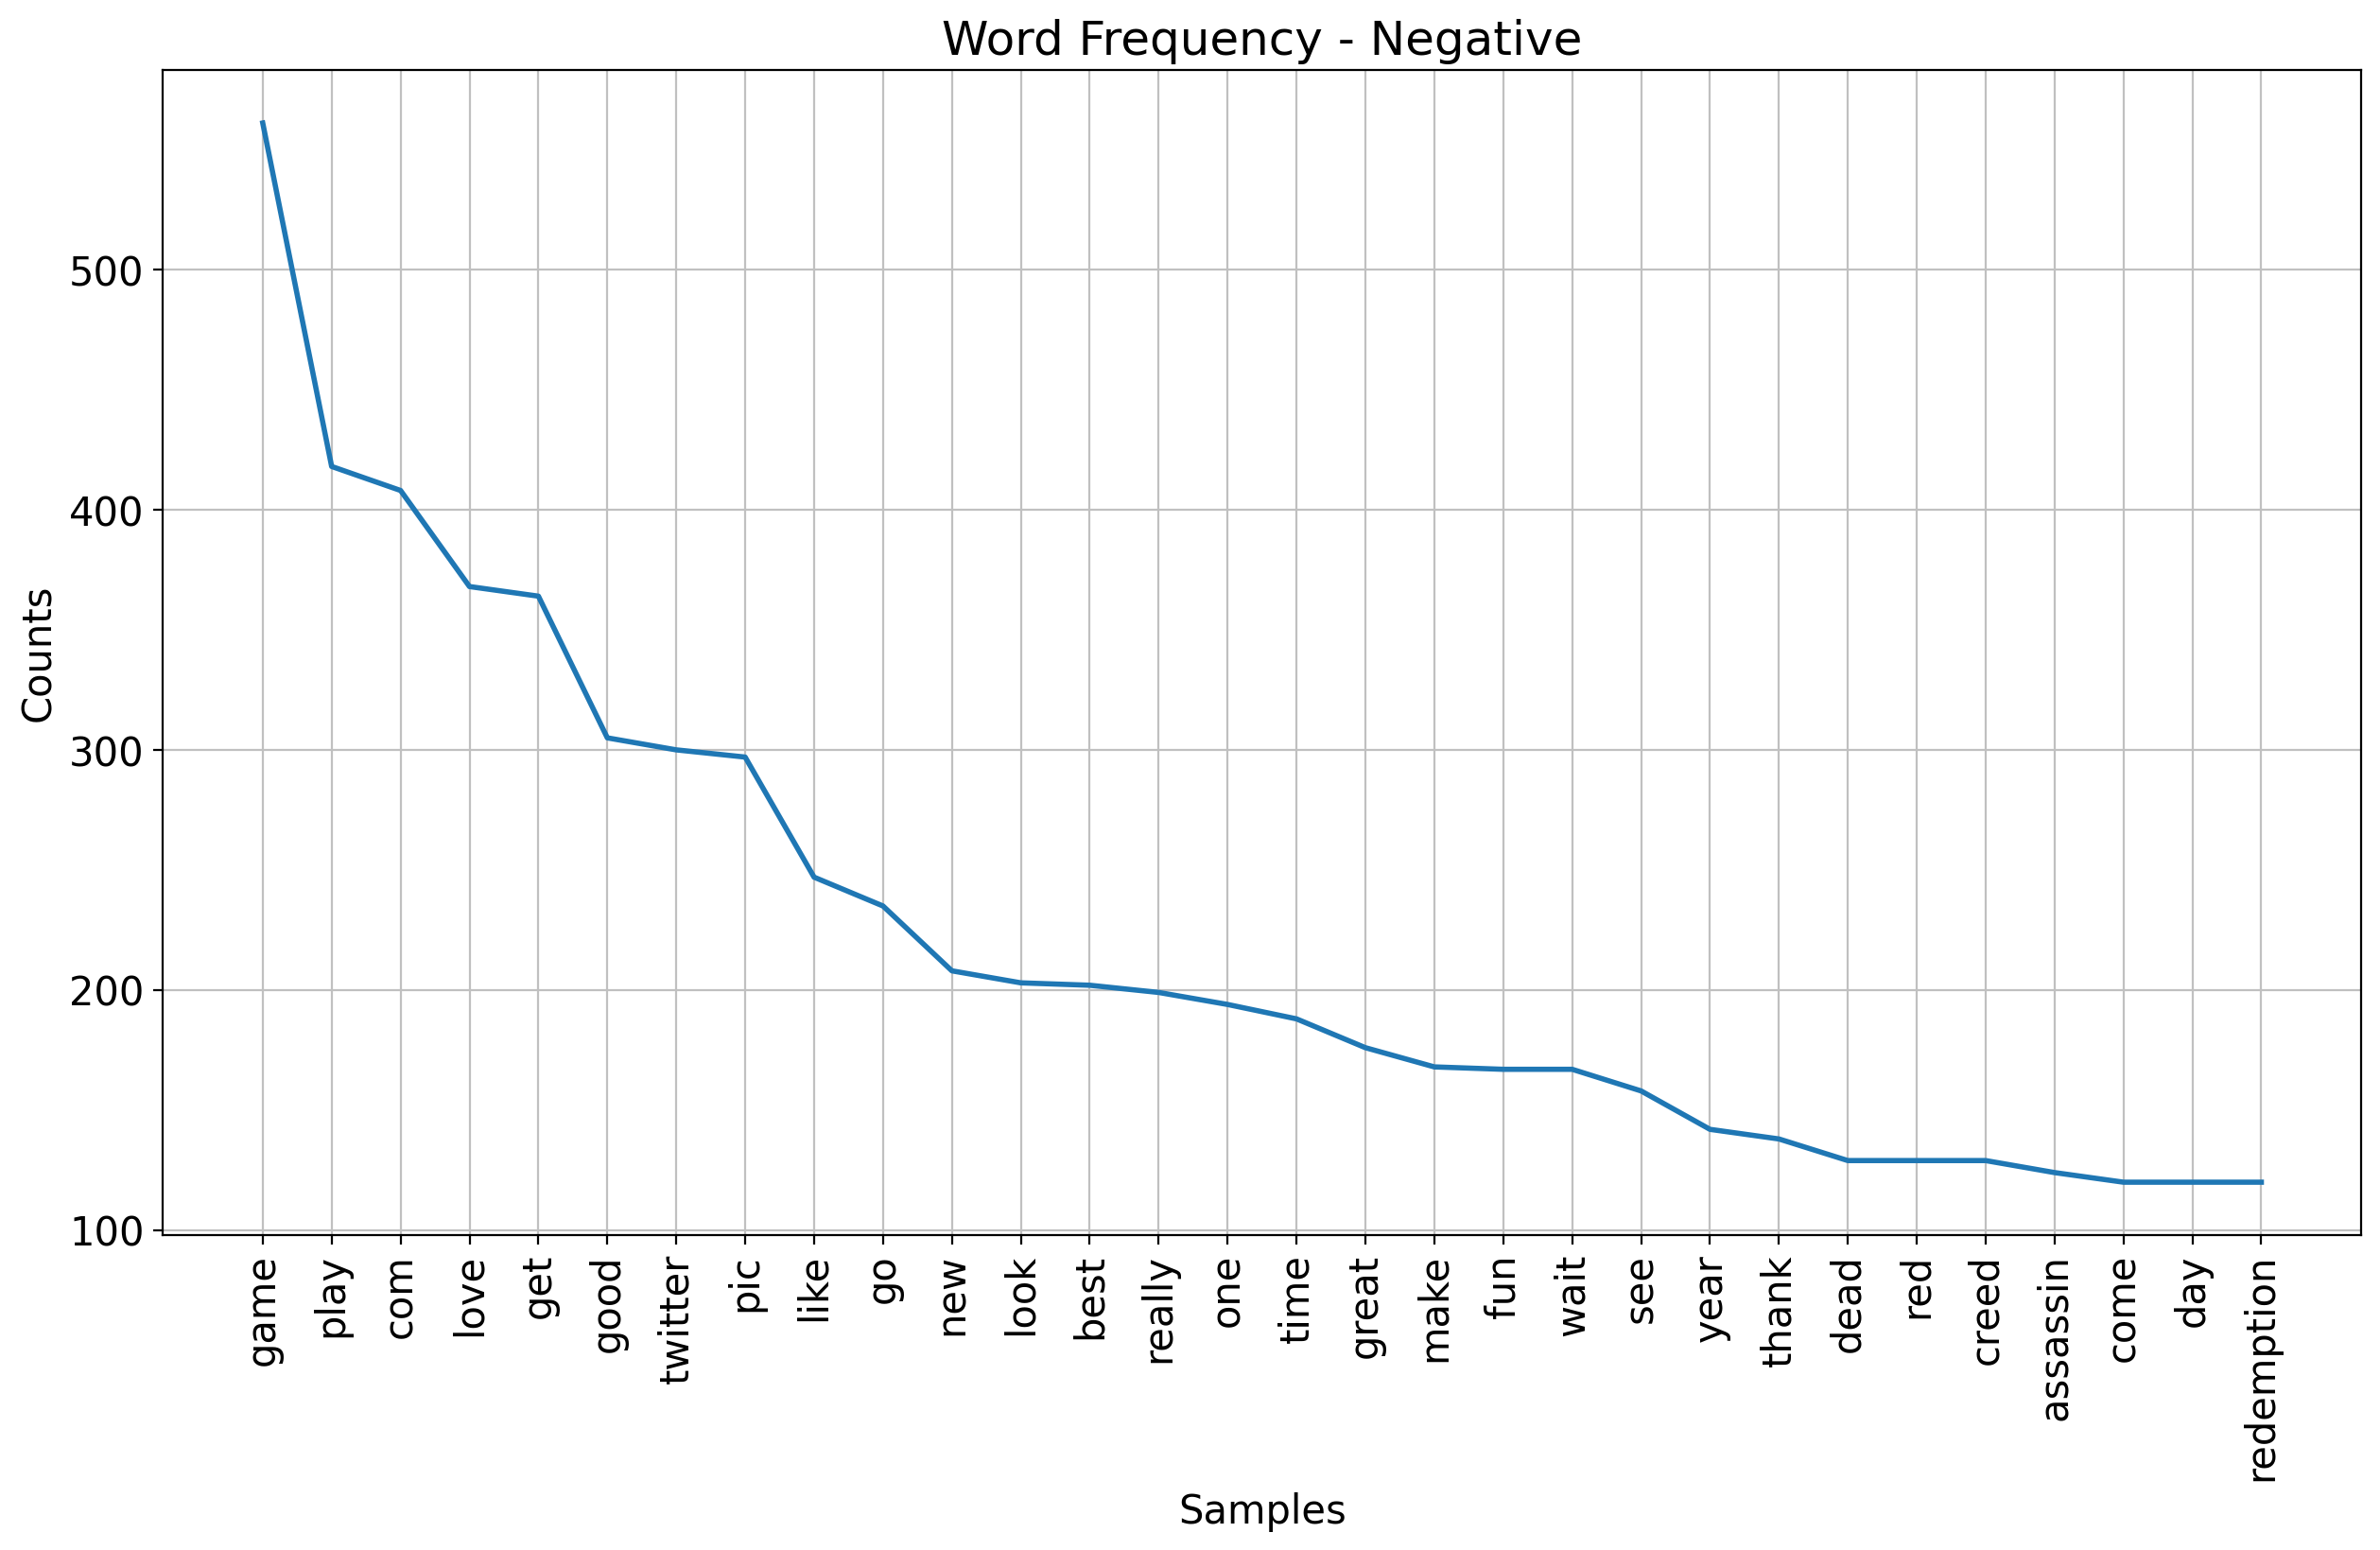

In [97]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (15,8)
plt.rcParams['font.size'] = 15
freq.plot(30, cumulative=False, title='Word Frequency - Negative')

### Word Cloud Visualization

#### collocations = False

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

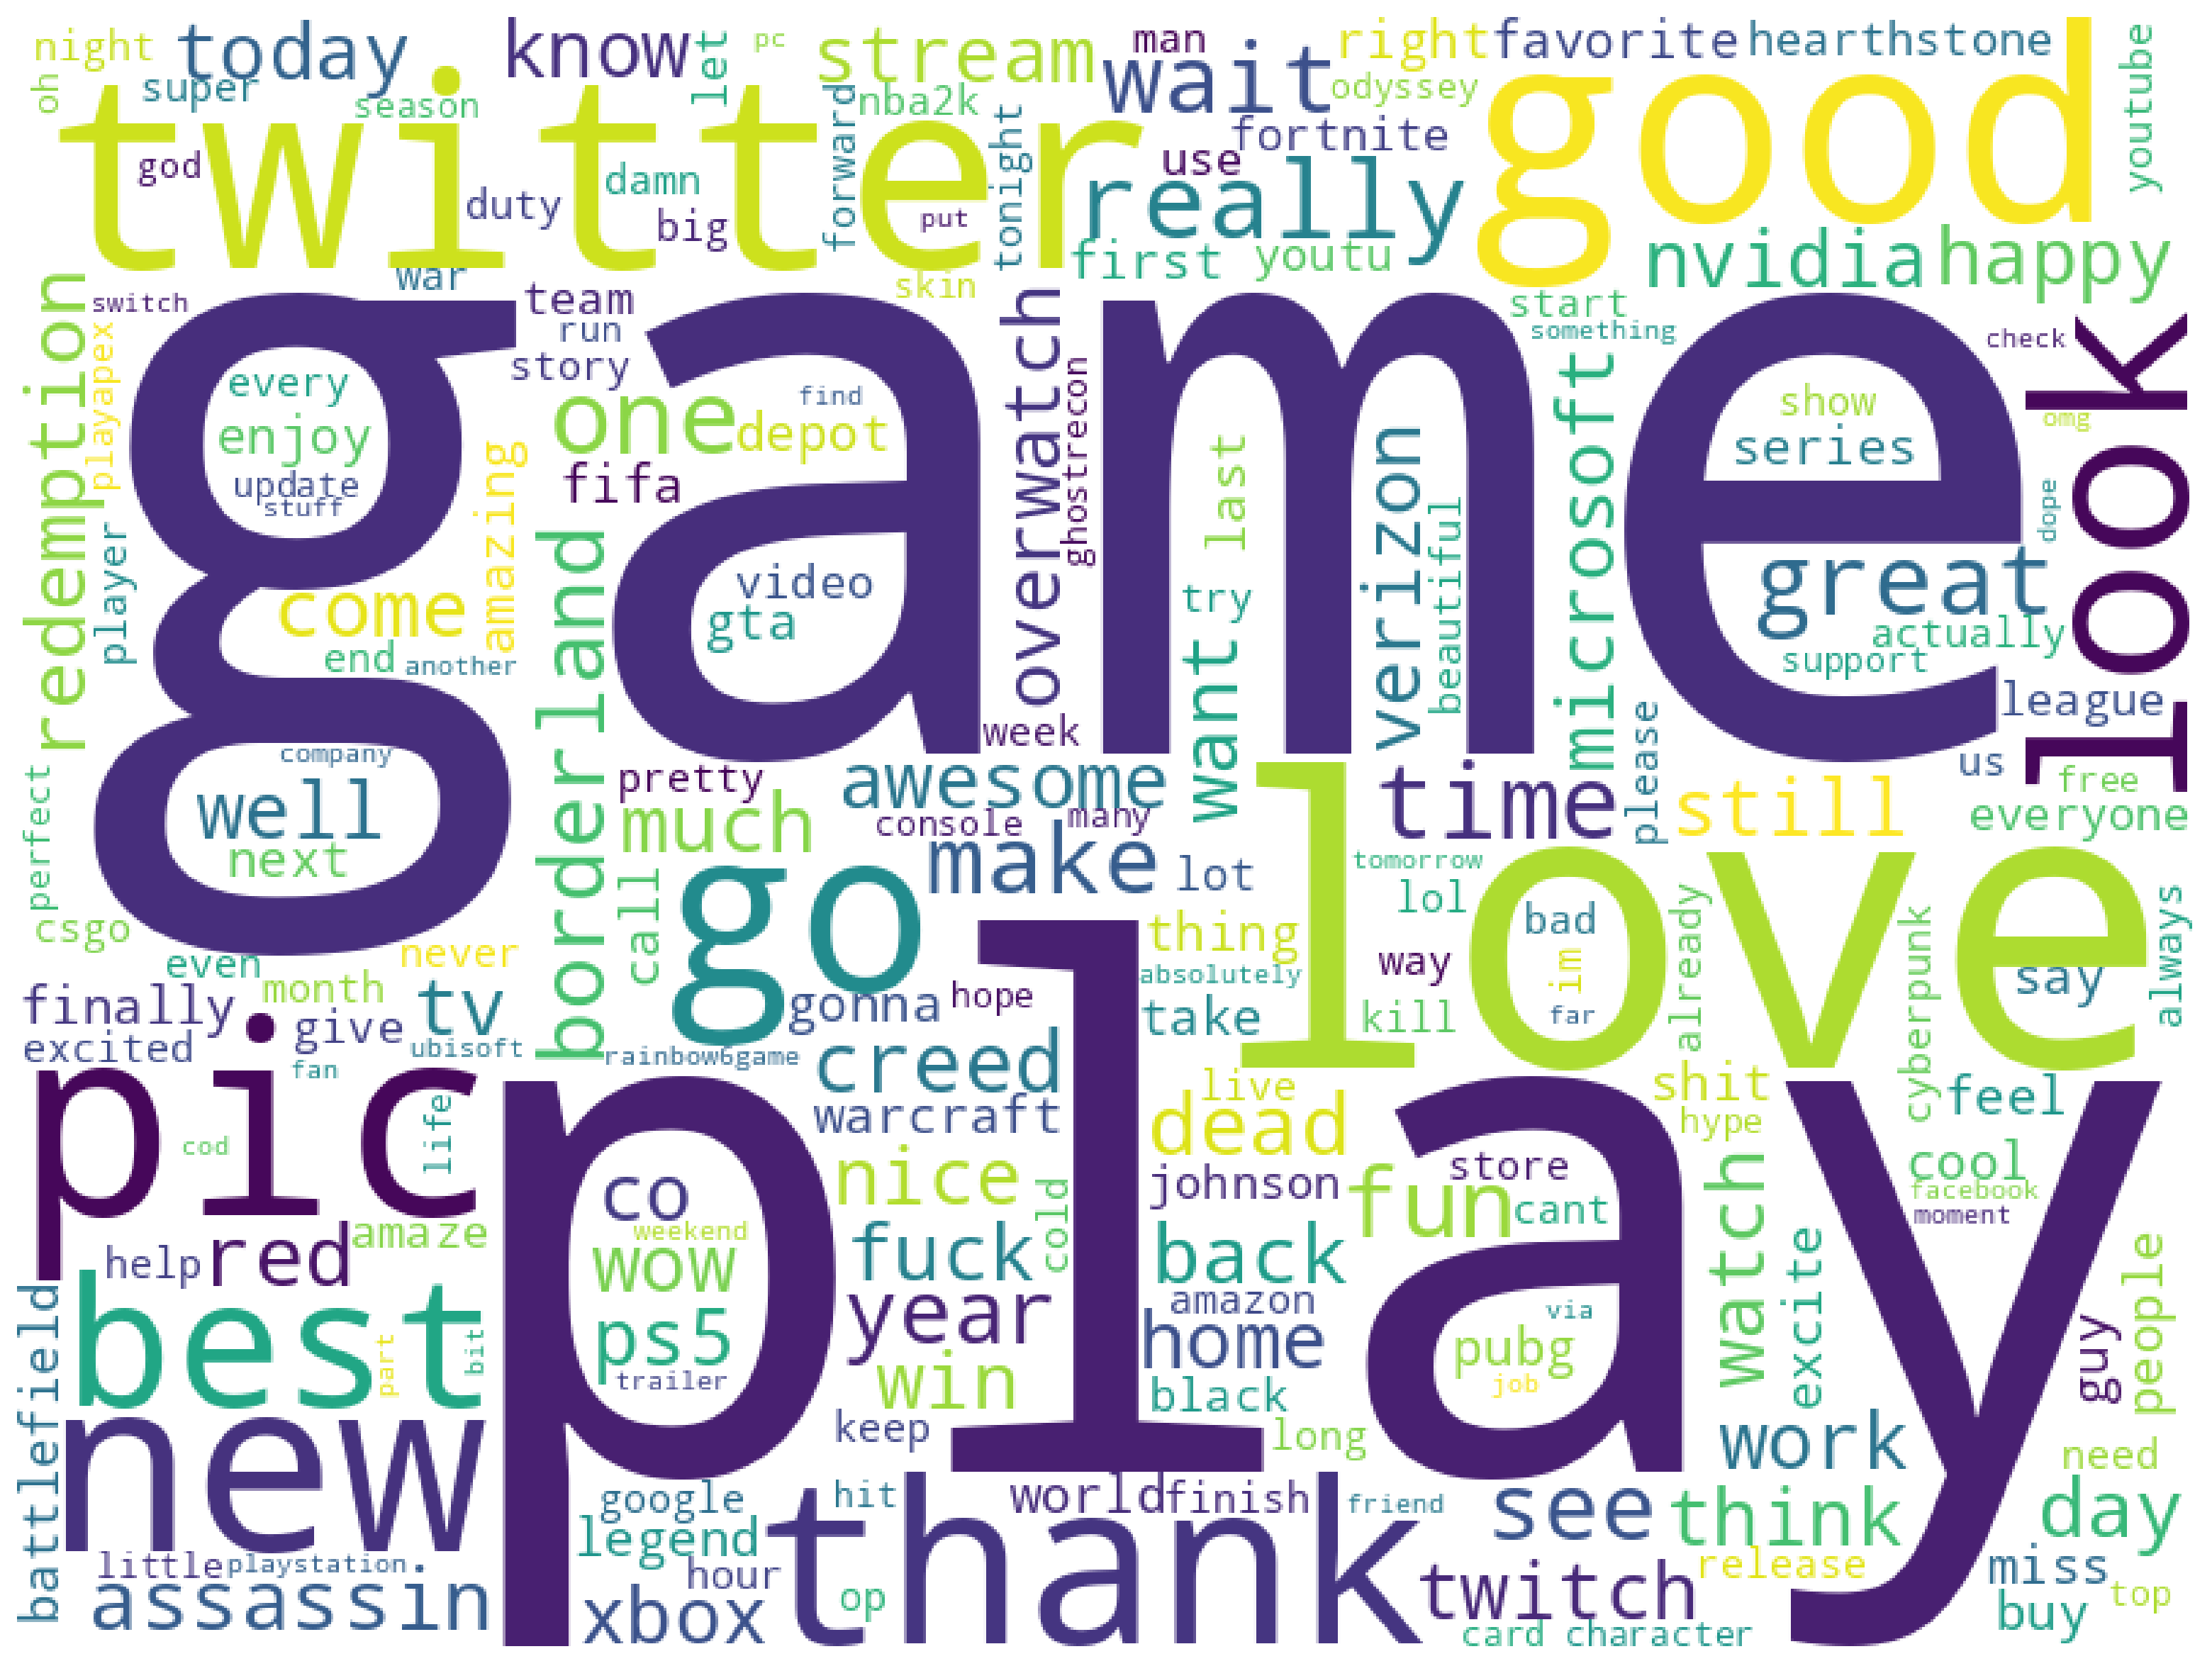

In [98]:
# collocations = False
from wordcloud import WordCloud

cloud = WordCloud(width=800, height=600, collocations=False, background_color = 'white').generate(" ".join(lemmatized_word))
plt.figure(figsize=(20,15))
plt.imshow(cloud)
plt.axis('off')

#### collocations = True

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

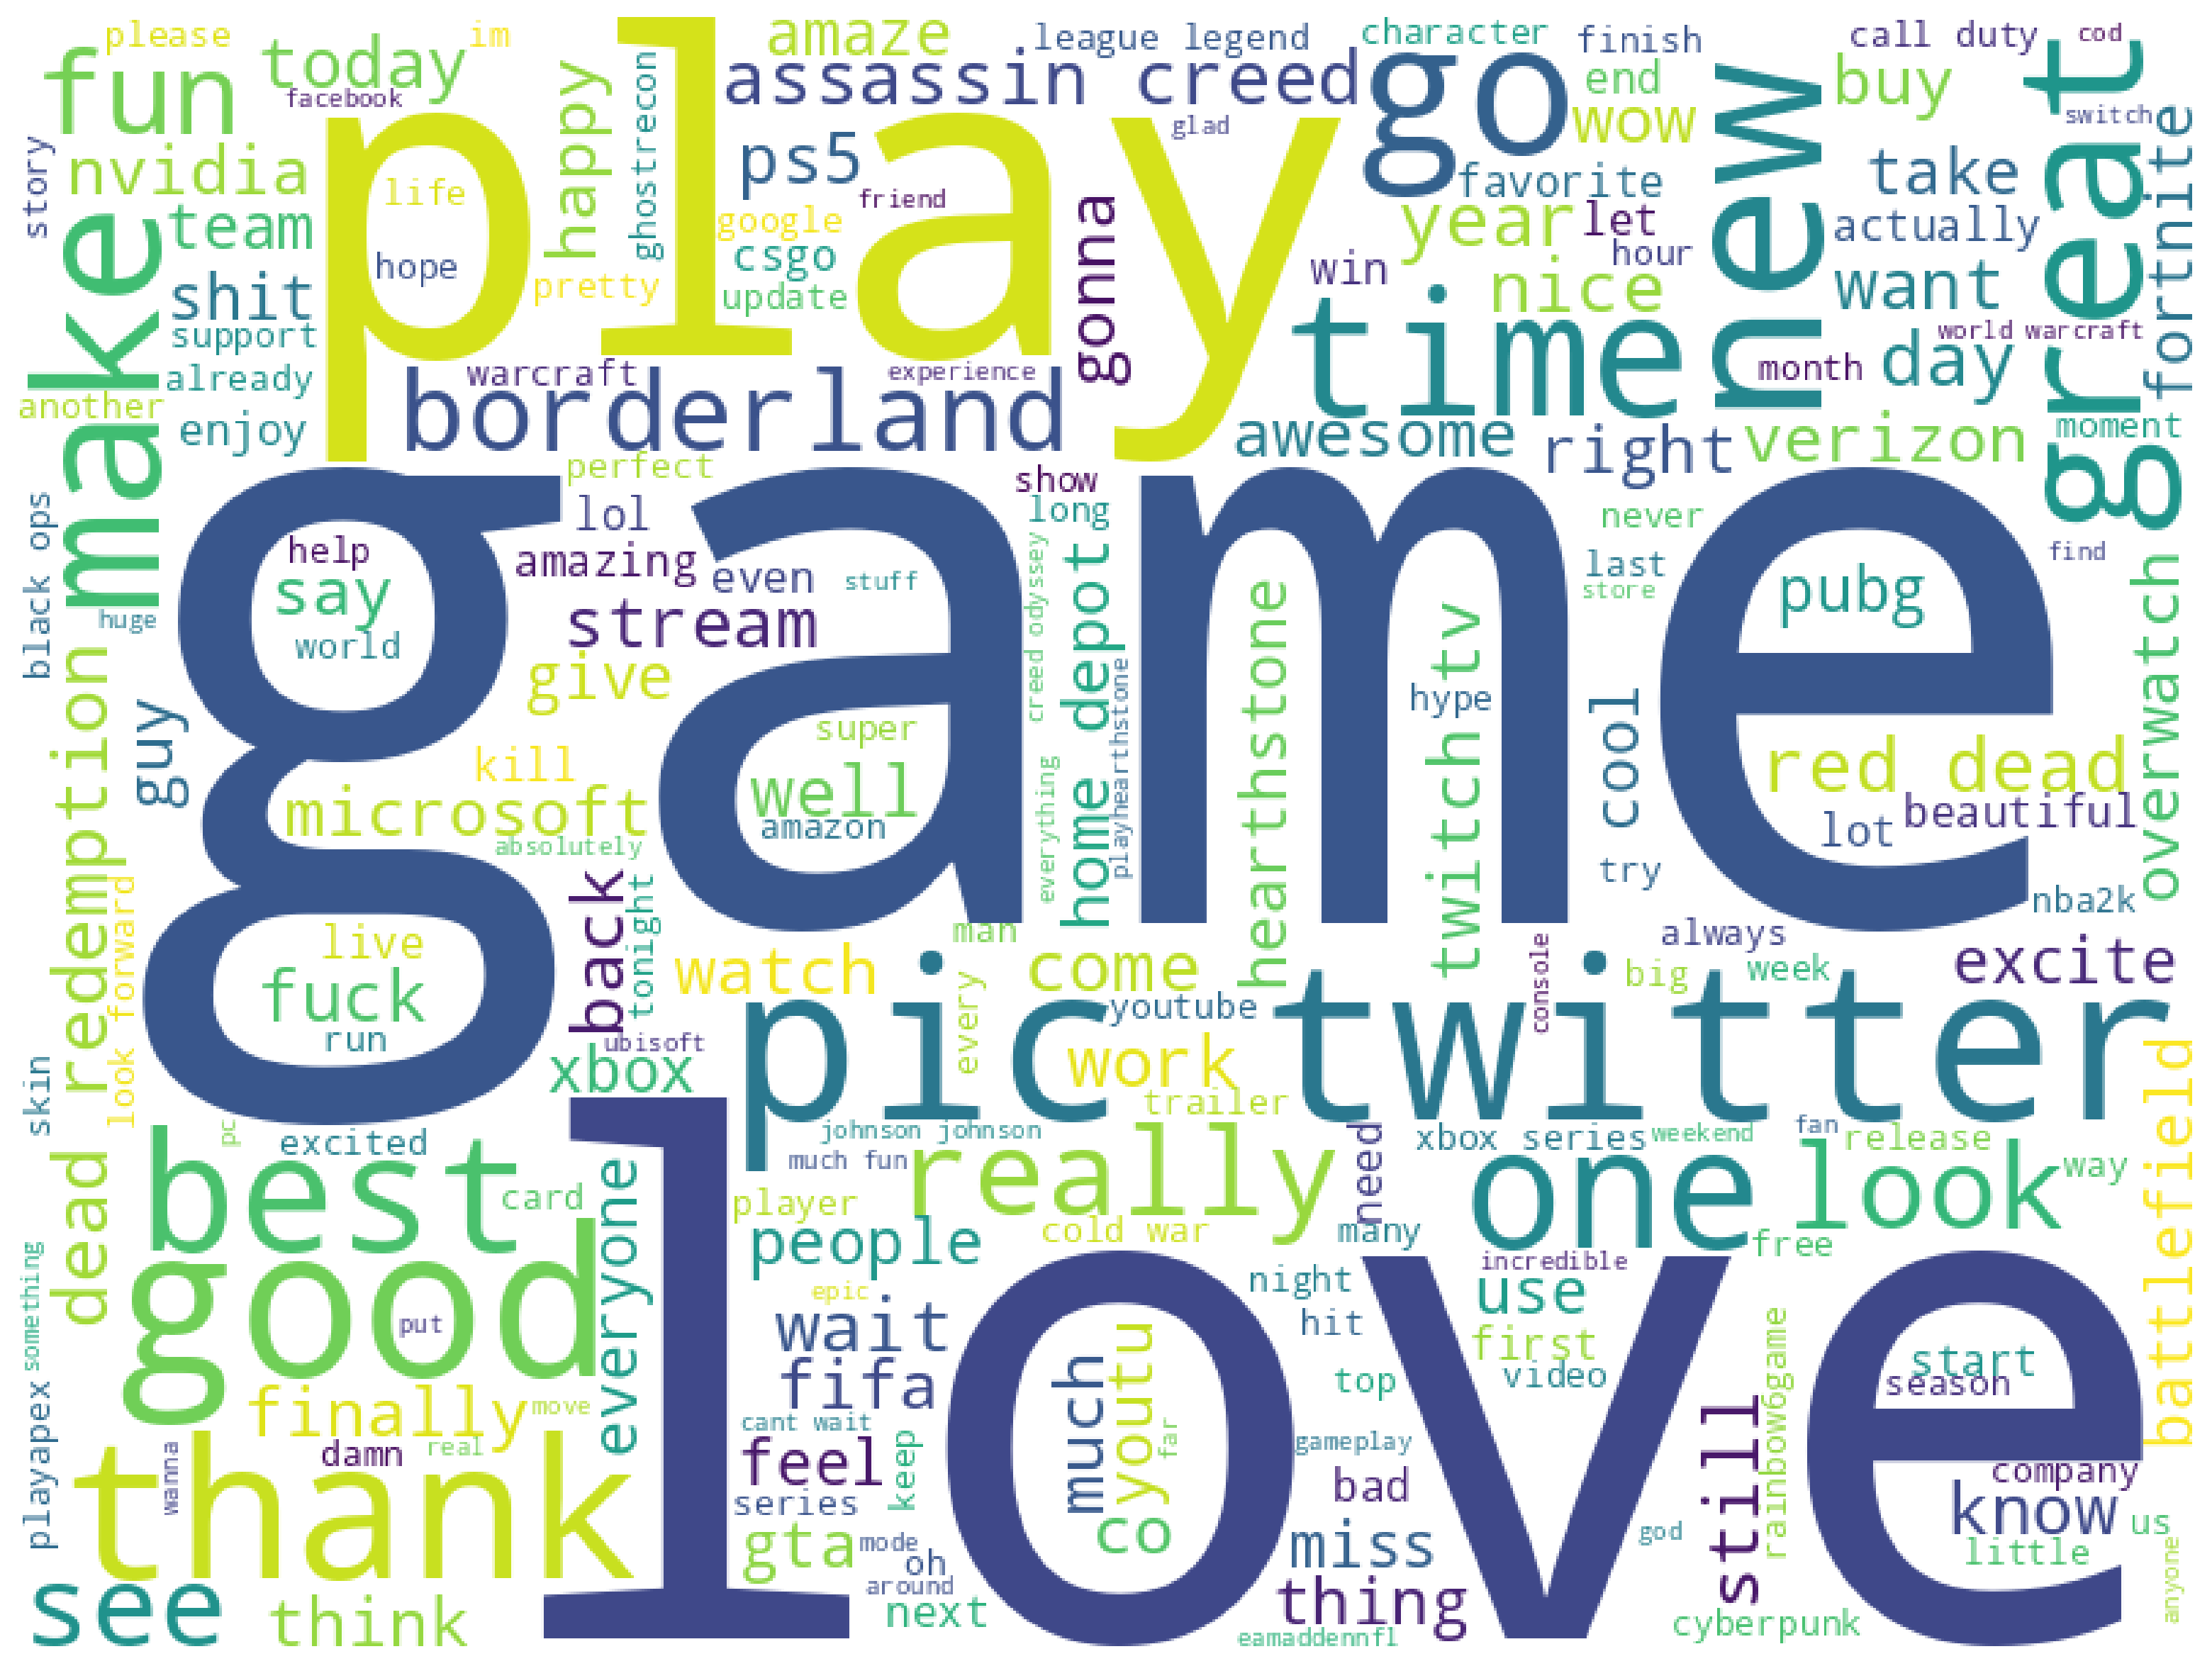

In [99]:
# collocations = True
from wordcloud import WordCloud

cloud = WordCloud(width=800, height=600, background_color = 'white').generate(" ".join(lemmatized_word))
plt.figure(figsize=(20,15))
plt.imshow(cloud)
plt.axis('off')

#### Bigram wordcloud

In [100]:
from nltk import bigrams
bgram = bigrams(lemmatized_word)
bgram_list = [x for x in bgram]

In [101]:
from collections import Counter

c = Counter(bgram_list)
print(c.most_common(30))

[(('twitter', 'com'), 294), (('pic', 'twitter'), 288), (('assassin', 'creed'), 122), (('red', 'dead'), 121), (('dead', 'redemption'), 119), (('twitch', 'tv'), 94), (('home', 'depot'), 70), (('http', 'co'), 61), (('league', 'legend'), 47), (('call', 'duty'), 45), (('black', 'ops'), 41), (('xbox', 'series'), 41), (('cold', 'war'), 38), (('look', 'forward'), 33), (('cyberpunk', '2077'), 31), (('johnson', 'johnson'), 30), (('cant', 'wait'), 29), (('creed', 'odyssey'), 27), (('world', 'warcraft'), 26), (('much', 'fun'), 25), (('ops', 'cold'), 24), (('https', 'co'), 23), (('play', 'game'), 23), (('really', 'good'), 20), (('really', 'enjoy'), 20), (('look', 'like'), 19), (('game', 'ever'), 19), (('game', 'play'), 18), (('love', 'game'), 18), (('video', 'game'), 18)]


In [102]:
"_".join(bgram_list[0])

'im_get'

In [103]:
for i in range(0,len(bgram_list)):
    bgram_list[i] = "_".join(bgram_list[i])

In [104]:
Bigram_Freq = nltk.FreqDist(bgram_list)

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

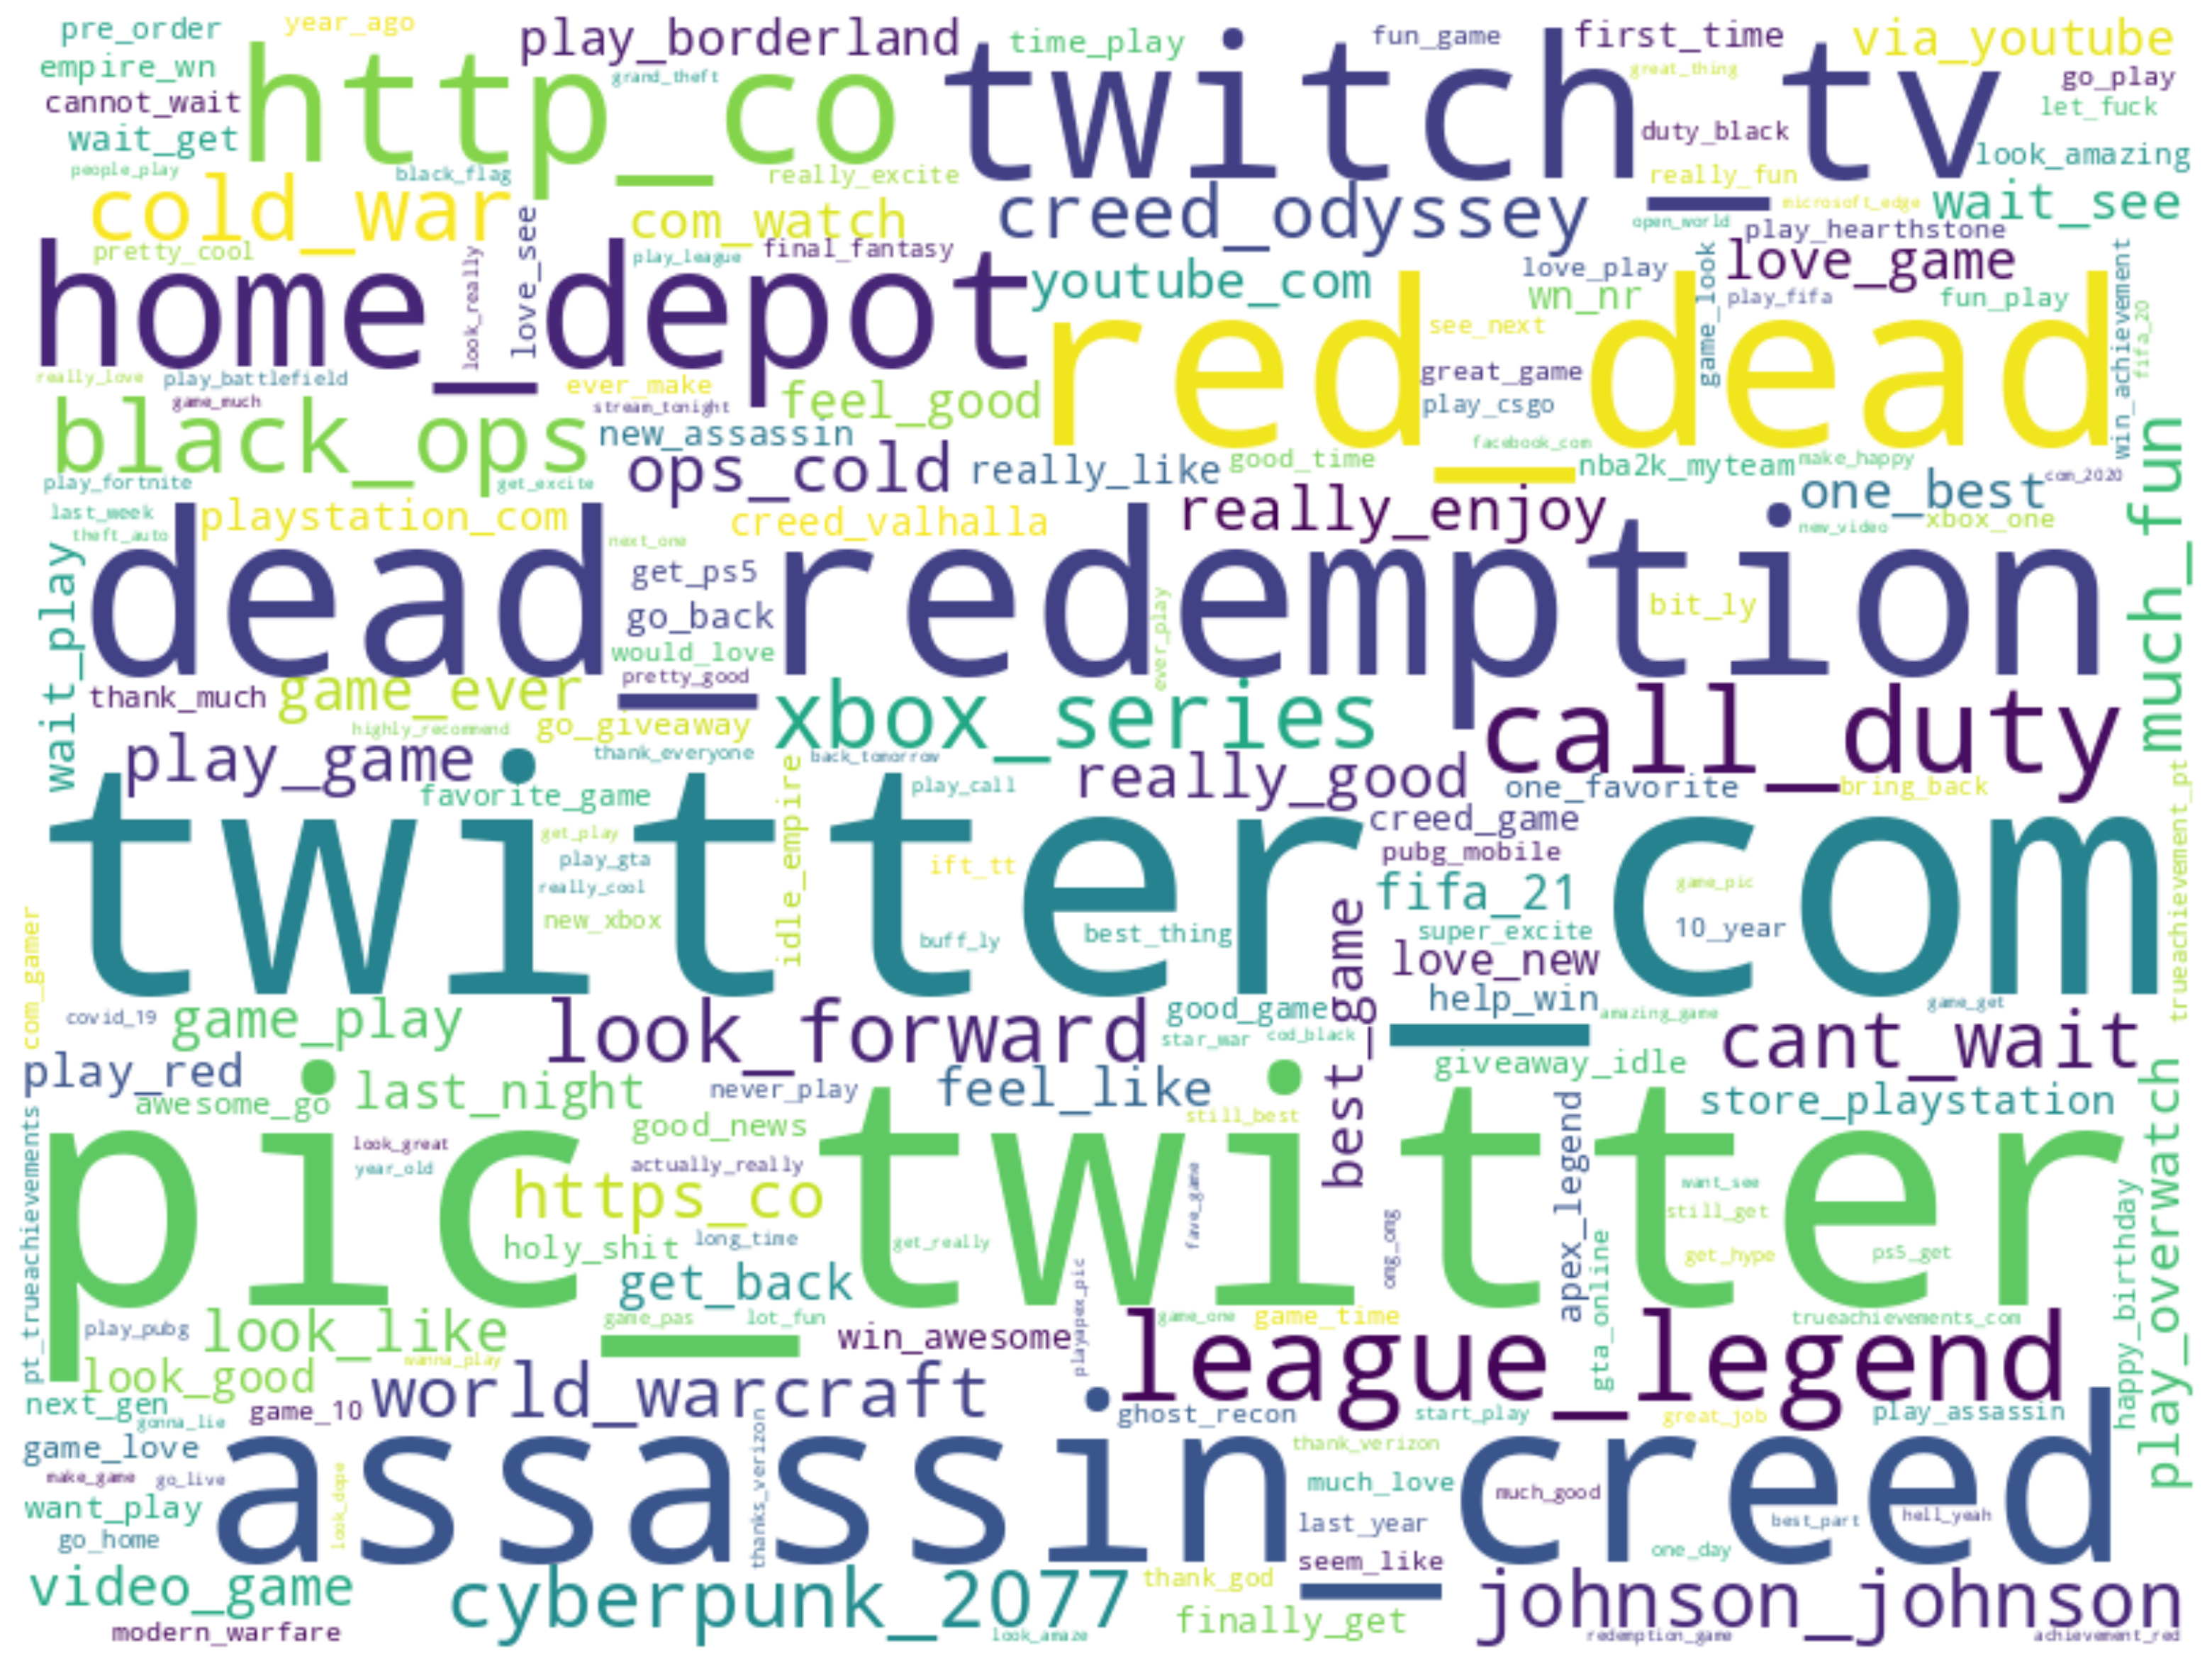

In [105]:
# bigram wordcloud
from wordcloud import WordCloud

bigram_wordcloud = WordCloud(width=800, height=600, background_color = 'white').generate_from_frequencies(Bigram_Freq)
plt.figure(figsize = (20,15))
plt.imshow(bigram_wordcloud, interpolation = 'bilinear')
plt.axis("off")